# Time Step Finding

In [ ]:
from pathlib import Path
import sys
import os
import pickle
import copy
import numpy as np
import time
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 0. Setup Paths and Imports
# -----------------------------------------------------------------------------
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer

# -----------------------------------------------------------------------------
# 1. Define Configurations for Both Datasets
# -----------------------------------------------------------------------------
configs = [
    {
        'experiment_type': 'OptiHorst',
        'config_file': "config_OptiHorst.yaml",
        'data_path': Path(r"D:\mbc_nba\OptiHorst\Daten\Abtauen\CSV_Export"),
        'group_name':"-1°C",
        'exp_ids': [25,26,27,28,64],
        'use_melted_mass': None
    },

    # {
    #     'experiment_type': 'OptiAbt',
    #     'config_file': "config_OptiAbt.yaml",
    #     'data_path': Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export"),
    #     'group_name': "+3 °C",
    #     'exp_ids': [52, 53, 55, 56],
    #     'use_melted_mass': True # Specifically requested for OptiAbt
    # }
]

time_steps_to_test = [240, 120, 60, 30, 10, 5, 1]
cutoff_pct = 0.05
all_combined_results = {}

# -----------------------------------------------------------------------------
# 2. Simulation Loop
# -----------------------------------------------------------------------------
for conf in configs:
    exp_type = conf['experiment_type']
    group = conf['group_name']
    
    print(f"\n{'='*80}")
    print(f"STARTING SENSITIVITY ANALYSIS for: {exp_type} (Group: {group})")
    print(f"{'='*80}")
    
    analyzer = MultiExperimentAnalyzer(experiment_type=exp_type)
    sim = FrostEvaporatorSimulation(conf['config_file'])
    viz = SimulationVisualizer(sim.params)
    
    results = []
    
    for i, dt in enumerate(time_steps_to_test):
        start_time = time.time() 
        
        sim.update_time_step(dt)
        exp_data = analyzer.analyze(
            exp_ids=conf['exp_ids'], 
            data_path=conf['data_path'], 
            cutoff_pct=cutoff_pct, 
            time_step=sim.params.time_step
        )
        
        states_history, inputs_history = sim.run_validation(exp_data)
        
        # Build arguments for plot_comparison dynamically
        plot_kwargs = {
            'states_history': states_history,
            'inputs_history': inputs_history,
            'experiment_ids': conf['exp_ids'],
            'path_exp': conf['data_path'],
            'cutoff_pct': cutoff_pct,
            'save_fig': False,
            'group_name': group,
            'experiment_name': exp_type
        }

        if conf['use_melted_mass'] is not None:
            plot_kwargs['use_melted_mass'] = conf['use_melted_mass']
            
        viz.plot_comparison(**plot_kwargs)
        
        # Extract data from the LAST time step (t = -1)
        last_state = states_history[-1]
        final_frost_mass_kg = sum(layer.frost.mass * sim.params.global_register_amount for layer in last_state)
        final_dp_pa = sum(layer.air.pressure_drop for layer in last_state)
        final_q_tot_w = sum(layer.hmt.Q_dot_total * sim.params.global_register_amount for layer in last_state)
        
        elapsed_time = time.time() - start_time
                
        results.append({
            'run': i + 1,
            'dt': dt,
            'mass': final_frost_mass_kg, 
            'dp': final_dp_pa, 
            'q': final_q_tot_w, 
            'sim_time': elapsed_time
        })
        
    # Calculate Deviations (%) against the 1s reference run
    ref_run = next(res for res in results if res['dt'] == 1)
    ref_mass, ref_dp, ref_q = ref_run['mass'], ref_run['dp'], ref_run['q']

    table_width = 105 
    print("=" * table_width)
    print(f"{'Lauf':<5} | {'dt':<4} | {'Reifmasse':<10} | {'Abw. %':<8} | {'Druckverlust':<12} | {'Abw. %':<8} | {'Wärmestrom':<10} | {'Abw. %':<8} | {'Sim. Zeit':<9}")
    print("-" * table_width)

    for res in results:
        res['dev_mass'] = ((res['mass'] - ref_mass) / ref_mass * 100) if ref_mass else 0.0
        res['dev_dp'] = ((res['dp'] - ref_dp) / ref_dp * 100) if ref_dp else 0.0
        res['dev_q'] = ((res['q'] - ref_q) / ref_q * 100) if ref_q else 0.0
        
        run, dt_str = res['run'], f"{res['dt']} s"
        mass_str, dp_str, q_str = f"{res['mass']:.4f} kg", f"{res['dp']:.2f} Pa", f"{res['q']:.2f} W"
        time_str = f"{res['sim_time']:.2f} s"
        
        if res['dt'] == 1:
            dm_str, ddp_str, dq_str = "-", "-", "-"
        else:
            dm_str = f"{res['dev_mass']:+5.2f} %"
            ddp_str = f"{res['dev_dp']:+5.2f} %"
            dq_str = f"{res['dev_q']:+5.2f} %"
            
        print(f"{run:<5} | {dt_str:<4} | {mass_str:<10} | {dm_str:<8} | {dp_str:<12} | {ddp_str:<8} | {q_str:<10} | {dq_str:<8} | {time_str:<9}")

    print("=" * table_width)
    
    # Store results for this experiment type
    all_combined_results[exp_type] = results

# -----------------------------------------------------------------------------
# 3. Save Data to Pickle
# -----------------------------------------------------------------------------
save_path = "simulation_data/final/04_evaporator_timestep_study_final_2.pkl"

print(f"\nSaving combined data to {save_path}...")
with open(save_path, "wb") as f:
    pickle.dump(all_combined_results, f)


In [ ]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# =============================================================================
# 1. GLOBALE PLOT-EINSTELLUNGEN (Vorgaben für Masterarbeit)
# =============================================================================
cm_to_inch = 1 / 2.54
width_cm = 15.5
# 3:2 Verhältnis als harmonischer Standard
height_cm = width_cm * (2/4)

plt.rcParams.update({
    # Maße und Auflösung
    "figure.figsize": (width_cm * cm_to_inch, height_cm * cm_to_inch),
    "figure.dpi": 300,
    
    # Schriftarten und LaTeX-Integration
    "text.usetex": True,
    # icomma sorgt dafür, dass das Komma in Matheumgebungen keinen falschen Abstand erzeugt
    "text.latex.preamble": r"\usepackage{icomma} \usepackage{amsmath}",
    "font.family": "serif",
    
    # Exakte Schriftgrößen laut Vorgaben
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Linien
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    
    # Legende und Export
    "legend.frameon": False,
    "savefig.bbox": "tight",
    "savefig.format": "pdf"
})

# ERC / RWTH Farbpalette
colors = {
    "blue": "#00549F",      # Druckverlust
    "red": "#DD402D",       # Wärmestrom
    "green": "#70AD47",     # Reifmasse
    "dark_grey": "#4E4F50", # Simulationszeit / Referenzlinie
    "mid_grey": "#9D9EA0",  # Toleranzbänder
    "light_grey": "#D9D9D9" # Grid
}

# =============================================================================
# 2. HILFSFUNKTIONEN
# =============================================================================
def german_formatter(x, pos):
    r"""
    Formatiert die Achsenticks ins deutsche Format (Komma statt Punkt).
    Nutzt den TeX Math-Mode, welcher durch \usepackage{icomma} sauber gesetzt wird.
    """
    return f"${x:g}$".replace('.', ',')

# =============================================================================
# 3. DATEN LADEN UND PLOTTEN
# =============================================================================
save_path = r"D:\mbc_nba\vclibpy\frost_evaporator_nba\notebooks\simulation_data\final\04_evaporator_timestep_study_final_2.pkl"

print(f"Loading data from {save_path} for plotting...\n")
with open(save_path, "rb") as f:
    loaded_results = pickle.load(f)

m_style, m_size = 'o', 4

for exp_type, data in loaded_results.items():
    # Filtert alle Einträge mit dt = 480 raus
    data = [d for d in data if d['dt'] != 480]

    print(f"Generating zeitschrittstudie plot for {exp_type}...")
    
    dt_labels = [str(d['dt']) for d in data]
    reifmasse = np.array([d['mass'] for d in data])
    druckverlust = np.array([d['dp'] for d in data])
    waermestrom = np.array([d['q'] for d in data])
    sim_zeit = [d['sim_time'] for d in data]
    
    # Normierung in Prozent
    reif_norm = reifmasse / reifmasse[-1] * 100
    druck_norm = druckverlust / druckverlust[-1] * 100
    waerme_norm = waermestrom / waermestrom[-1] * 100
    
    # Umwandeln der Simulationszeit in Minuten
    sim_zeit = [t / 60.0 for t in sim_zeit]
    
    x = np.arange(len(dt_labels))
    
    # Plot aufbauen
    fig, ax1 = plt.subplots()
    
    # Grid nur auf der y-Achse (Z-Order = 0 für Hintergrund)
    ax1.grid(True, axis='y', linestyle='--', color=colors["light_grey"], alpha=0.7, zorder=0)
    ax1.set_axisbelow(True) # Zwingt das Grid in den Hintergrund
    
    # Rahmenlinien (Spines) entfernen (Oben komplett, rechts für ax1)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Primäre Achse: Daten zeichnen (zorder=3 sorgt dafür, dass sie VOR dem Grid liegen)
    line1 = ax1.plot(x, reif_norm, marker=m_style, markersize=m_size, color=colors["green"], zorder=3, label='Reifmasse')
    line2 = ax1.plot(x, druck_norm, marker=m_style, markersize=m_size, color=colors["blue"], zorder=3, label='Druckverlust')
    line3 = ax1.plot(x, waerme_norm, marker=m_style, markersize=m_size, color=colors["red"], zorder=3, label='Wärmestrom')
    
    # Achsenbeschriftungen (Mit Escaping für Prozentzeichen in LaTeX)
    ax1.set_xlabel(r'Zeitschrittgröße $\Delta t$ [s]')
    ax1.set_ylabel('Normierte Endwerte\n' r'(Ref. $\Delta t = 1\,$s) [\%]')
    
    # Tick-Beschriftungen formatieren
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"${l}$" for l in dt_labels])
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(german_formatter))
    
    # Horizontale Linien für Referenz und Toleranz (zorder=1 -> Hinter den Daten, vor dem Grid)
    line_100 = ax1.axhline(100, color=colors["dark_grey"], linestyle='-', alpha=0.6, linewidth=1.2, zorder=1, label='Referenz (1 s)')
    line_tol = ax1.axhline(101, color=colors["mid_grey"], linestyle='--', alpha=0.8, linewidth=1.2, zorder=1, label=r'$\pm 1\,\%$ Grenze')
    ax1.axhline(99, color=colors["mid_grey"], linestyle='--', alpha=0.8, linewidth=1.2, zorder=1)
    ax1.axhspan(99, 101, color=colors["mid_grey"], alpha=0.1, zorder=0)
    
    # Sekundäre Y-Achse für Simulationszeit
    ax2 = ax1.twinx()
    # Auch hier oberen Rahmen entfernen
    ax2.spines['top'].set_visible(False)
    
    line4 = ax2.plot(x, sim_zeit, marker=m_style, markersize=m_size, color=colors["dark_grey"], linestyle=':', zorder=3, label='Simulationszeit')
    
    # HIER WAR DER FEHLER: ax1.set_ylabel stand hier noch einmal, stattdessen jetzt ax2
    ax2.set_ylabel(r'Simulationszeit [min]')
    
    # Tick-Parameter & Deutsches Nummernformat auf sekundärer Achse
    ax2.tick_params(axis='y')
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(german_formatter))
    
    # Y-Achsen Limits
    ax1.set_ylim(98, 102)
    ax2.set_ylim(0, max(sim_zeit) * 1.1) # Dynamisch basierend auf der längsten Zeit, mit 10% Puffer
    
    # Legende (Ausgelagert & Zentriert oberhalb des Plots)
    ordered_lines = [line2[0], line_100, line3[0], line_tol, line1[0], line4[0]]
    ordered_labels = [l.get_label() for l in ordered_lines]
    
    # bbox_to_anchor verschiebt die Legende nach OBEN außerhalb der Axes-Fläche
    ax1.legend(ordered_lines, ordered_labels, loc='upper center', 
               bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=False)
    
    # Rendern & Speichern
    plt.tight_layout()
    
    # Zielordner als Raw-String (wichtig wegen der Backslashes!)
    output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
    
    # Dateiname generieren
    pdf_filename = f'4_zeitschritt_verd.pdf'
    
    # Ordner und Dateiname sicher zusammenfügen
    full_save_path = os.path.join(output_dir, pdf_filename)
    
    # Plot speichern
    plt.savefig(full_save_path, bbox_inches='tight')
    print(f"Plot erfolgreich gespeichert unter: {full_save_path}")

    plt.show()
    
    plt.close()

# OptiAbt Validation Data Generation

In [ ]:
from pathlib import Path
import sys
import os
import pickle
import copy

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer


##############################################################################################
# Opti Abt
##############################################################################################

path_exp_abt = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")
experiment_groups_abt = {
    "+3 °C":  [52, 53, 55, 56],
    "+0 °C":  [40, 41, 42, 43, 44],
    "-7 °C":  [27, 28, 29, 30],
    "-12 °C": [13, 18],
}
# experiment_groups_abt = {
#     "Abt-a": [56],
#     "Abt-b": [40],
#     "Abt-c": [28],
#     # "Abt-d": [13],
# }


analyzer_abt = MultiExperimentAnalyzer(experiment_type='OptiAbt')
sim_abt = FrostEvaporatorSimulation("config_OptiAbt.yaml")
viz_abt = SimulationVisualizer(sim_abt.params)
cutoff_pct = 0.05
all_sim_results = {}


for group_name, experiment_ids in experiment_groups_abt.items():
    
    print(f"\n{'='*40}")
    print(f"Processing Group: {group_name}")
    print(f"IDs: {experiment_ids}")
    print(f"{'='*40}")

    # Flag for the group that uses the melted mass measurement
    use_melted = False
    if group_name == "+3 °C" or group_name == "Abt-a":
        use_melted = True

    try:
        # Run analysis
        exp_data = analyzer_abt.analyze(
            exp_ids=experiment_ids, 
            data_path=path_exp_abt, 
            cutoff_pct=cutoff_pct, 
            time_step=sim_abt.params.time_step
        )

        # Run Simulation
        states_history, inputs_history = sim_abt.run_validation(exp_data)

        # Save the histories to our dictionary
        all_sim_results[group_name] = {
            'experiment_name': "OptiAbt",
            'path_exp'       : path_exp_abt,
            'params'         : copy.deepcopy(sim_abt.params),
            'experiment_ids' : experiment_ids,
            'cutoff_pct'     : cutoff_pct,
            'inputs_history' : inputs_history,
            'states_history' : states_history,
        }

        viz_abt.plot_comparison(states_history, inputs_history, experiment_ids, path_exp_abt, cutoff_pct, save_fig=False, group_name=group_name, experiment_name="OptiAbt", use_melted_mass=use_melted)
        # print(viz_abt.get_relative_error_table(states_history, inputs_history, experiment_ids, path_exp_abt, cutoff_pct, experiment_name="OptiAbt", use_melted_mass=use_melted))
        # viz_abt.plot_detailed(states_history, inputs_history, experiment_ids)
        # viz_abt.plot_roughness(states_history, experiment_ids[0])
        # viz_abt.plot_frost_distribution(states_history)
        # viz_abt.plot_debug(states_history, inputs_history, experiment_ids[0])

    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
        print(f"Error Message: {e}")
        traceback.print_exc()

# # Save the entire dictionary to a pickle file
# save_path = "simulation_data/optiabt_validation_test.pkl"
# with open(save_path, "wb") as f:
#     pickle.dump(all_sim_results, f)

# print(f"\nSuccessfully saved all simulation histories to: {save_path}")

# OptiHorst Validation Data Generation

In [ ]:
from pathlib import Path
import sys
import os
import pickle
import copy

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import MultiExperimentAnalyzer, FrostEvaporatorSimulation, SimulationVisualizer


##############################################################################################
# Opti Abt
##############################################################################################


path_exp_horst = Path(r"D:\mbc_nba\OptiHorst\Daten\Abtauen\CSV_Export")
experiment_groups_horst = {
    "+6°C":  [96,97,119,120,121],
    "-1°C":  [25,26,27,28,64],
    "-3°C":  [44,45,46,75],
    "-5°C":  [78,102,103,104],
    "-10°C": [60,61,62,83,84],
}


analyzer_horst = MultiExperimentAnalyzer(experiment_type='OptiHorst')
sim_horst      = FrostEvaporatorSimulation("config_OptiHorst.yaml")
viz_horst      = SimulationVisualizer(sim_horst.params)
cutoff_pct = 0.05
all_sim_results = {}


for group_name, experiment_ids in experiment_groups_horst.items():
    
    print(f"\n{'='*40}")
    print(f"Processing Group: {group_name}")
    print(f"IDs: {experiment_ids}")
    print(f"{'='*40}")

    try:
        # Run analysis
        exp_data = analyzer_horst.analyze(
            exp_ids=experiment_ids, 
            data_path=path_exp_horst, 
            cutoff_pct=cutoff_pct, 
            time_step=sim_horst.params.time_step
        )

        # Run Simulation
        states_history, inputs_history = sim_horst.run_validation(exp_data)

        # Save the histories to our dictionary
        all_sim_results[group_name] = {
            'experiment_name': "OptiHorst",
            'path_exp'       : path_exp_horst,
            'params'         : copy.deepcopy(sim_horst.params),
            'experiment_ids' : experiment_ids,
            'cutoff_pct'     : cutoff_pct,
            'inputs_history' : inputs_history,
            'states_history' : states_history,
        }

        # Plot 
        viz_horst.plot_comparison(states_history, inputs_history, experiment_ids, path_exp_horst, cutoff_pct, save_fig=False, group_name=group_name, experiment_name="OptiHorst")
        # viz_horst.plot_detailed(states_history, inputs_history, experiment_ids)
        # viz_horst.plot_roughness(states_history, experiment_ids[0])
        # viz_horst.plot_frost_distribution(states_history)
        # viz_horst.plot_debug(states_history, inputs_history, experiment_ids[0])
        

    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
        print(f"Error Message: {e}")
        traceback.print_exc()


# # Save the entire dictionary to a pickle file
# save_path = "simulation_data/optihorst_validation_test.pkl"
# with open(save_path, "wb") as f:
#     pickle.dump(all_sim_results, f)

# print(f"\nSuccessfully saved all simulation histories to: {save_path}")


# 3x3 Validation Plot

Grafik gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_BIG_4_Validierungsplot_abt_plus0_degC_1.svg
Grafik gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_BIG_4_Validierungsplot_abt_plus0_degC_2.svg
Grafik gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_BIG_4_Validierungsplot_abt_plus0_degC_3.svg


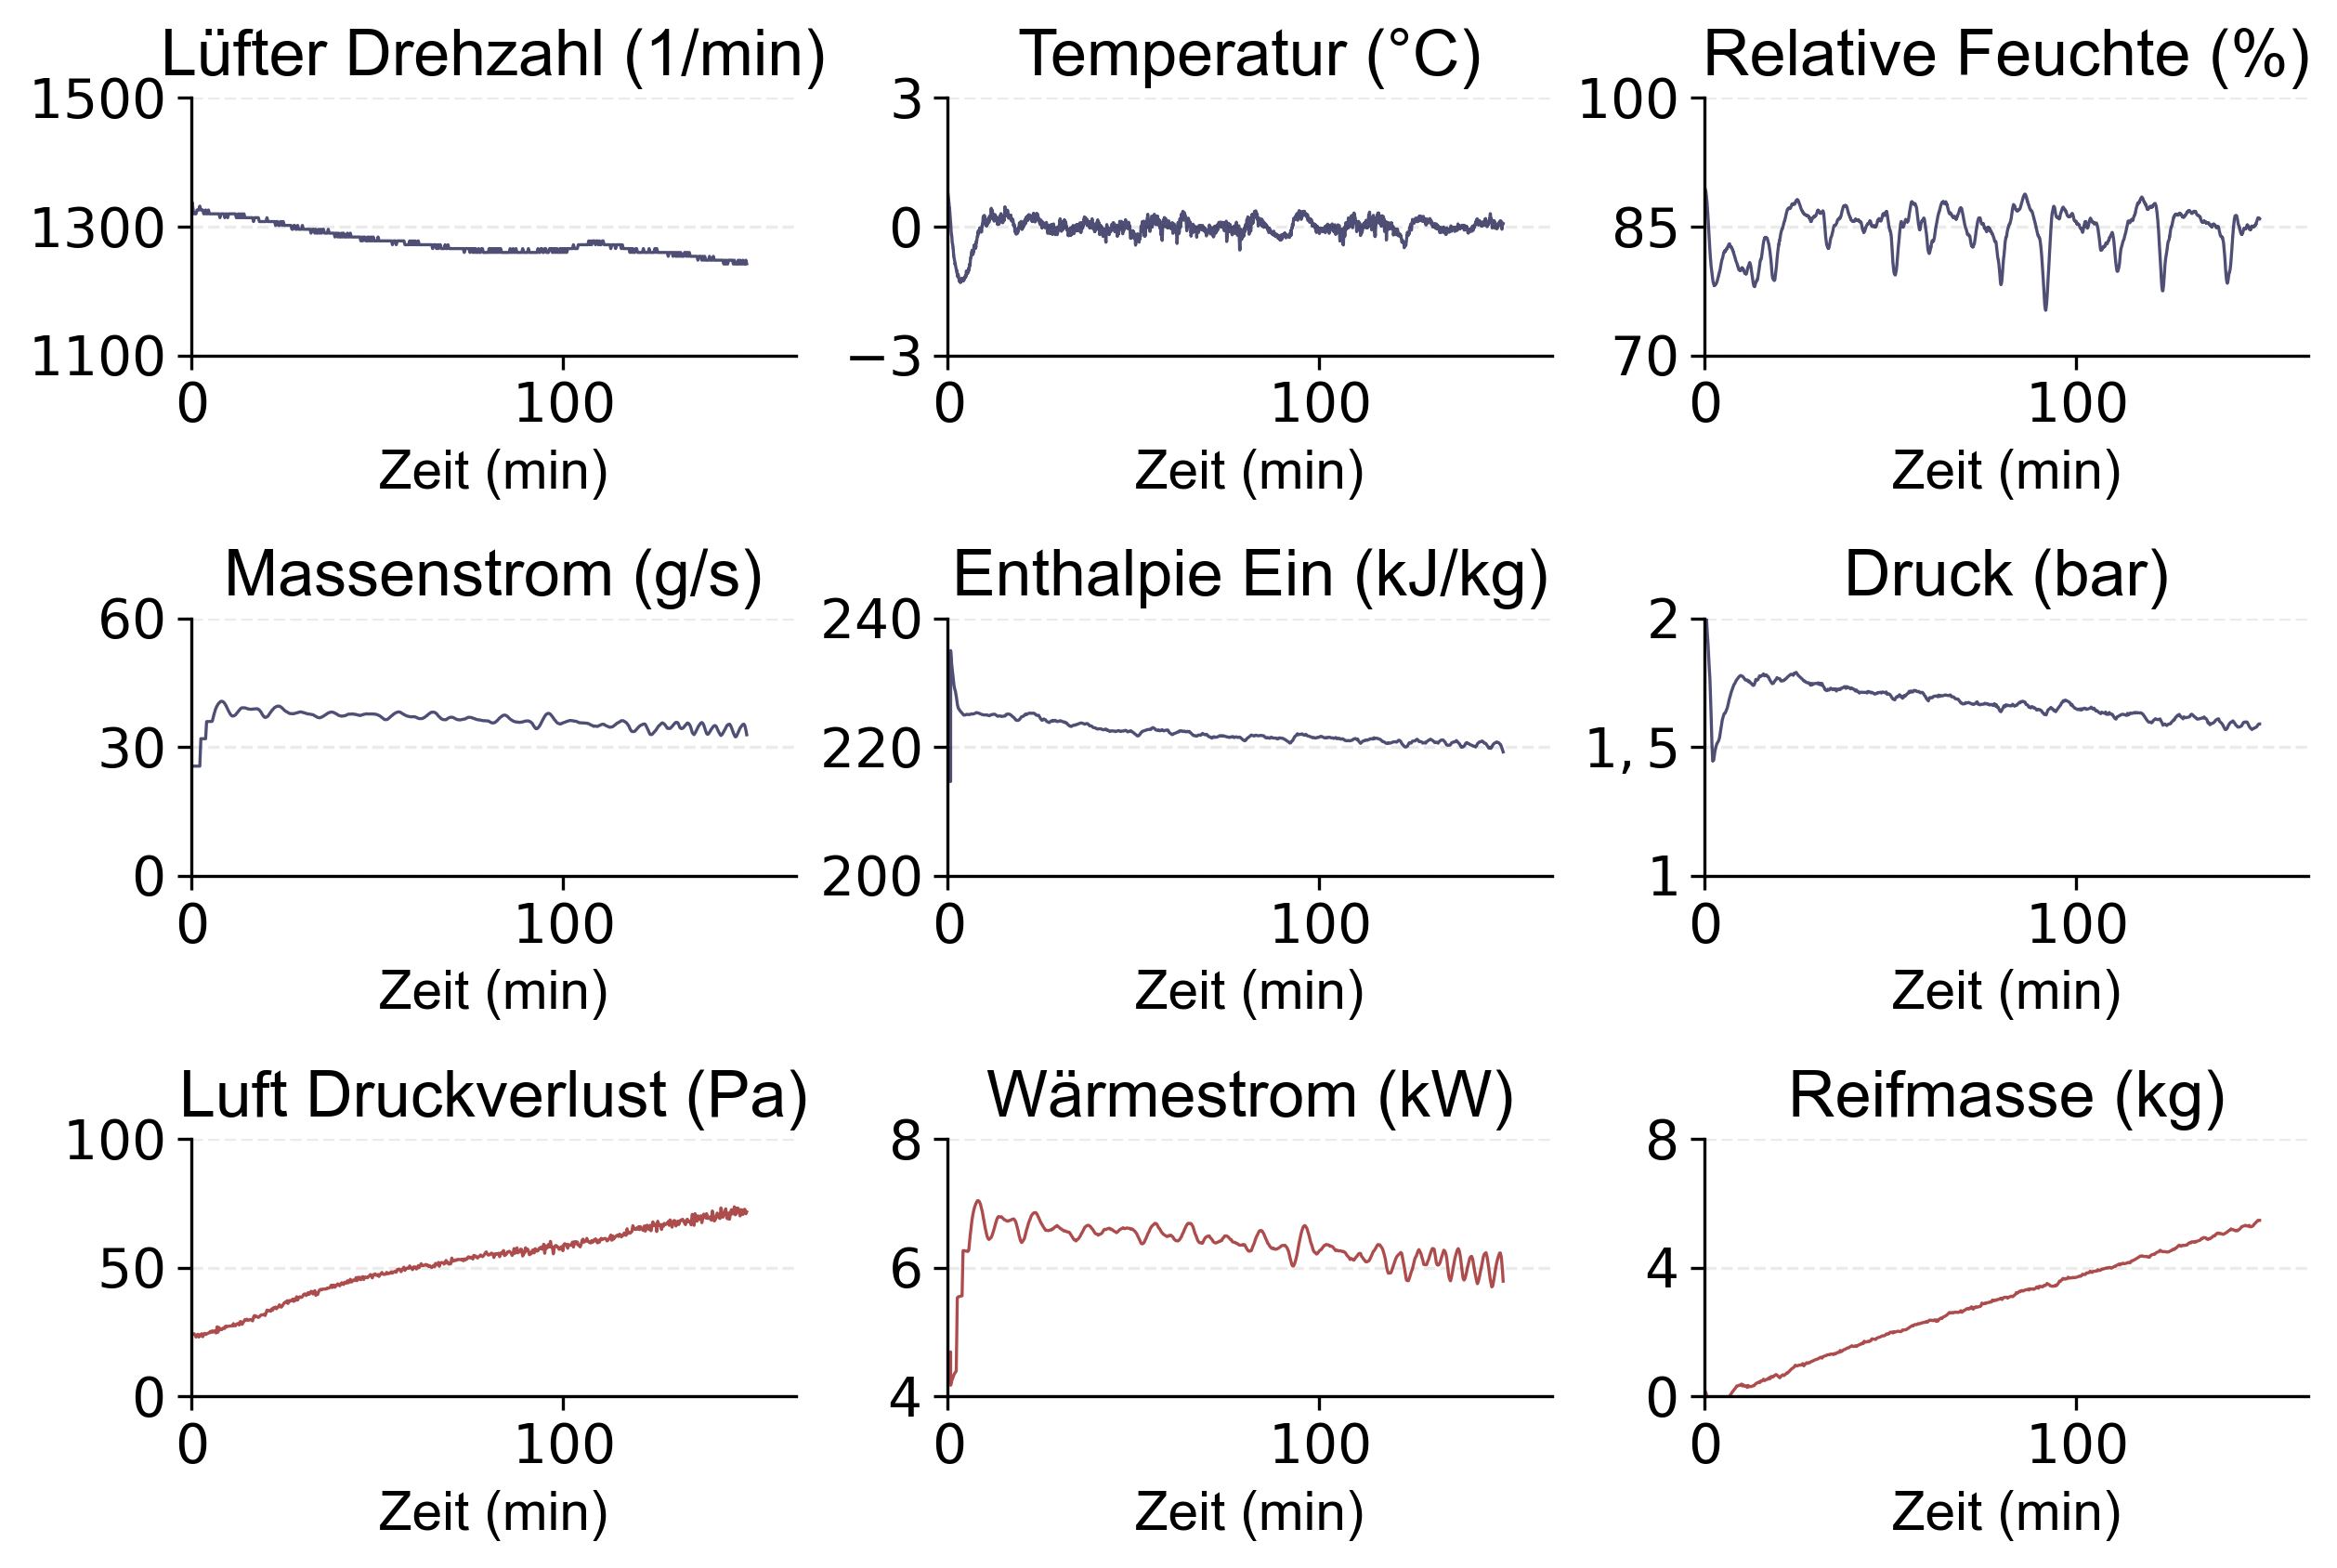

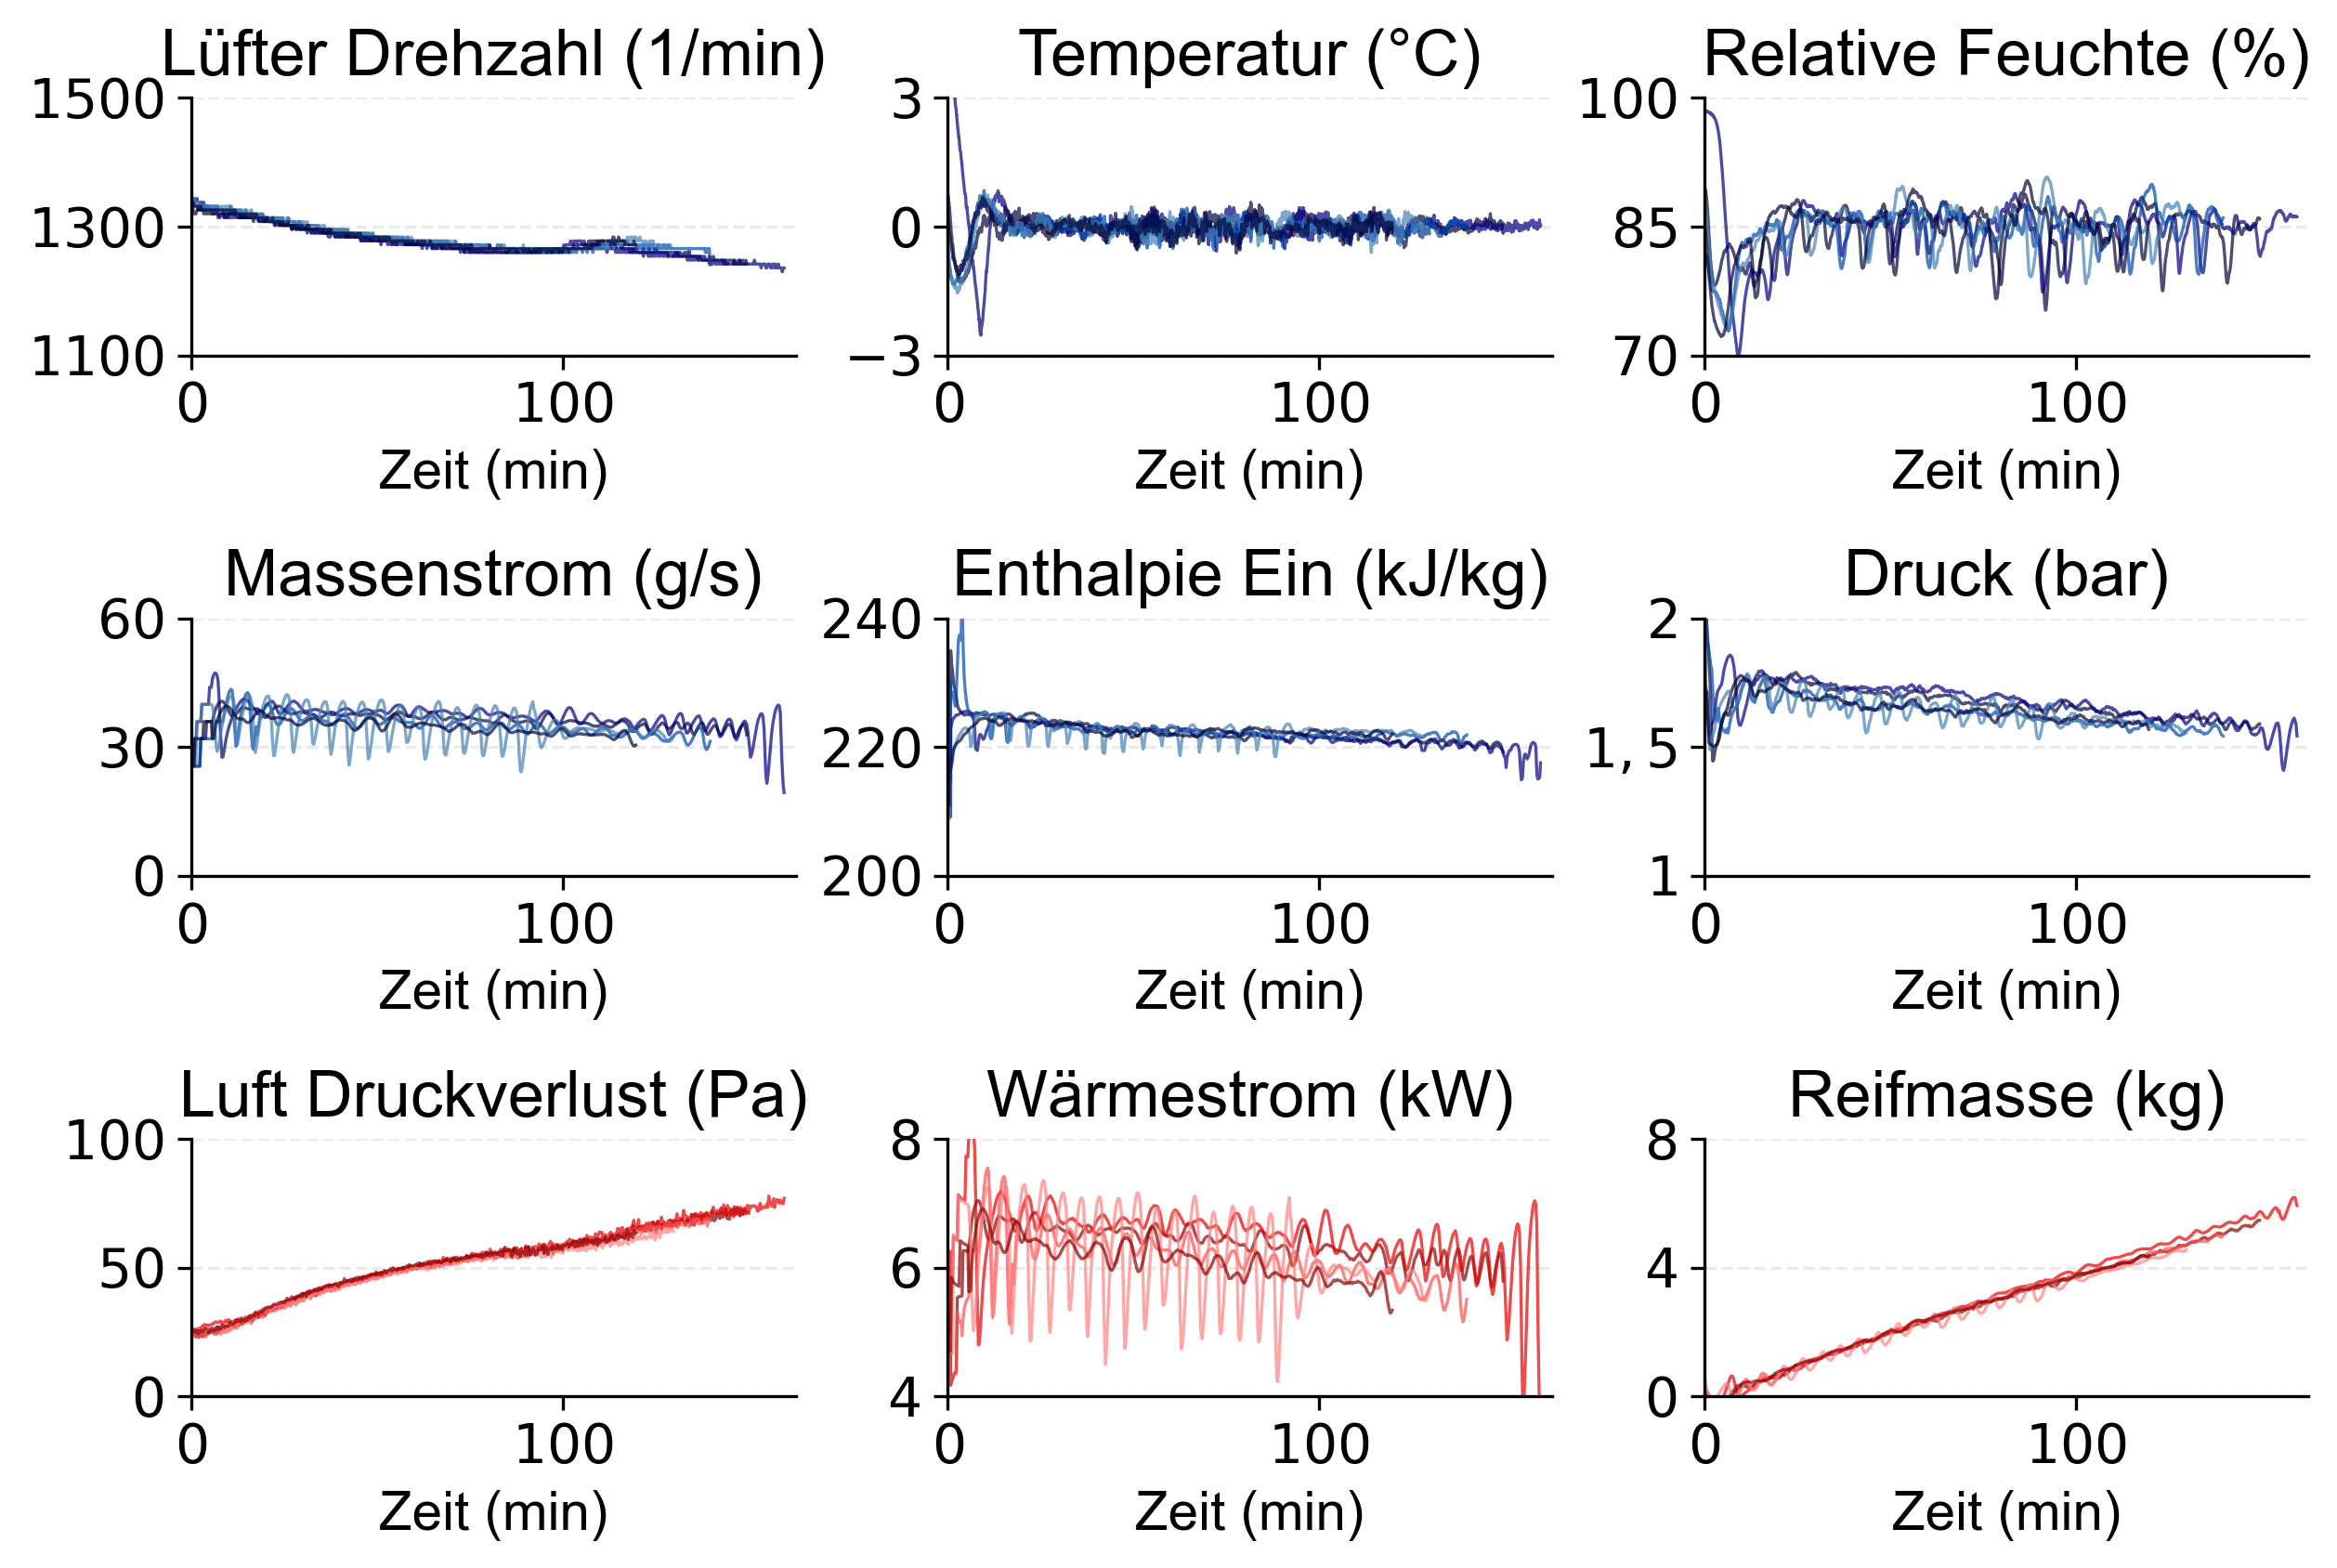

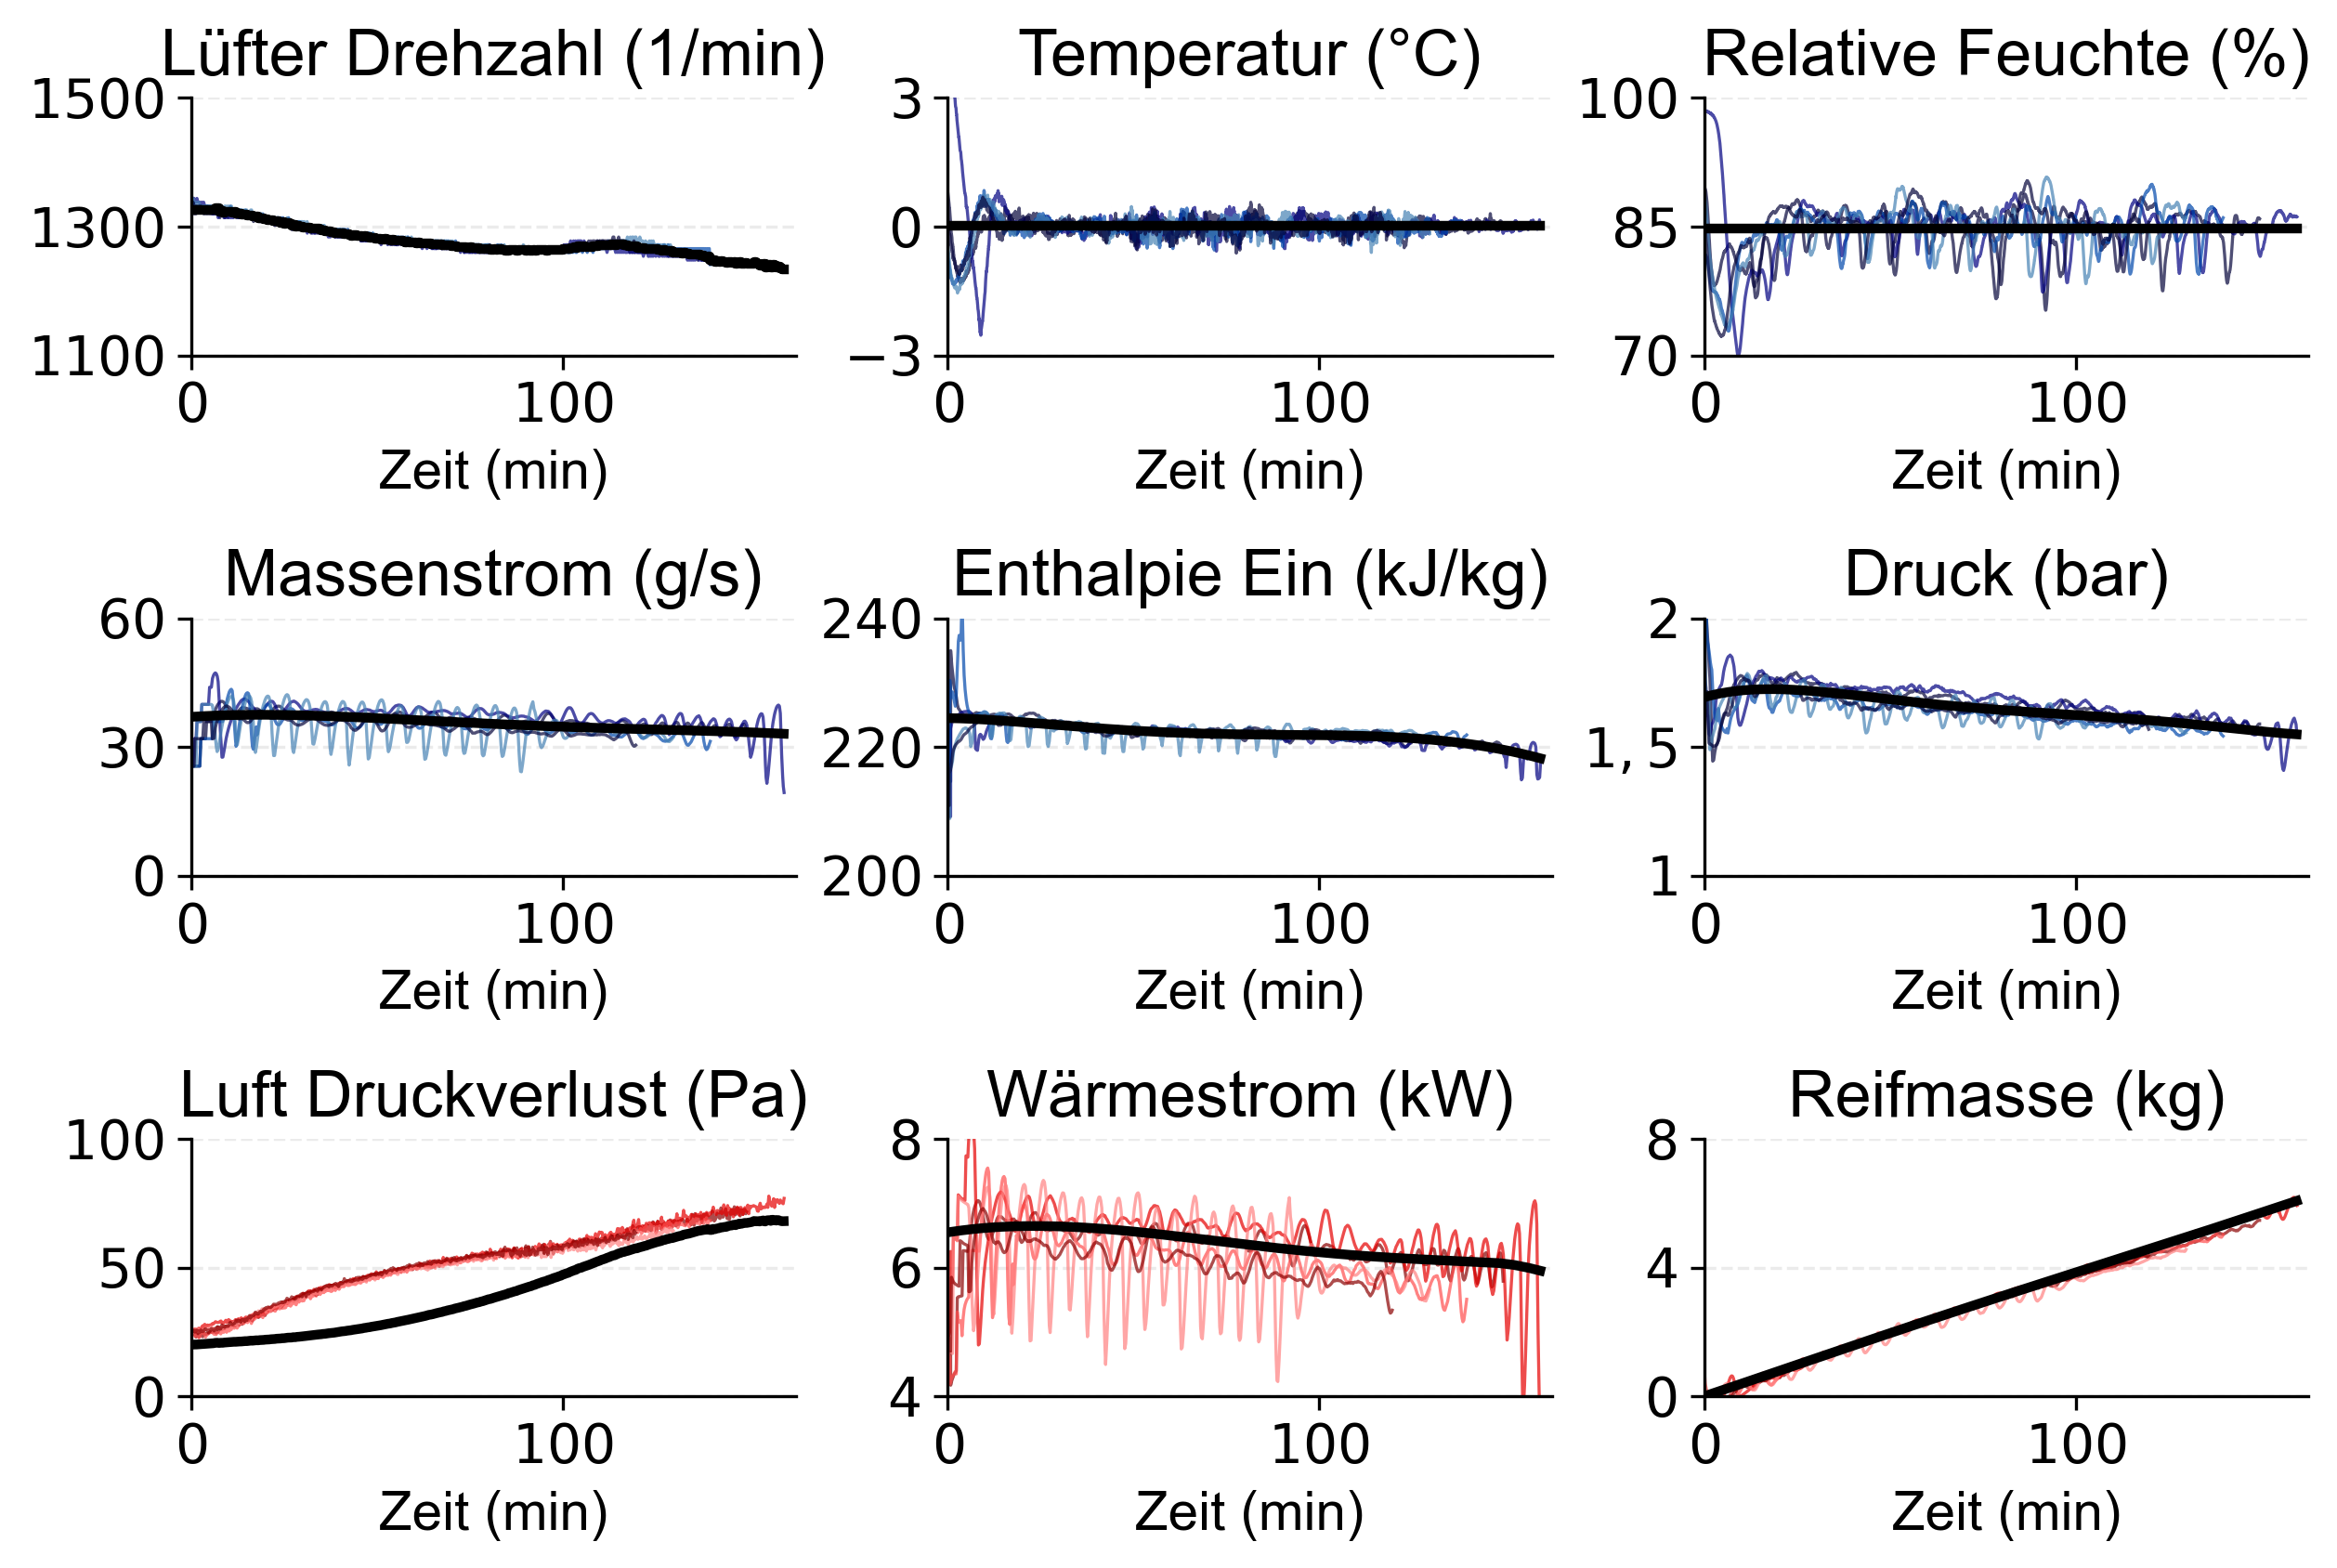

Grafik gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_BIG_4_Validierungsplot_horst_minus10degC_1.svg
Grafik gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_BIG_4_Validierungsplot_horst_minus10degC_2.svg
Grafik gespeichert: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\PP_BIG_4_Validierungsplot_horst_minus10degC_3.svg


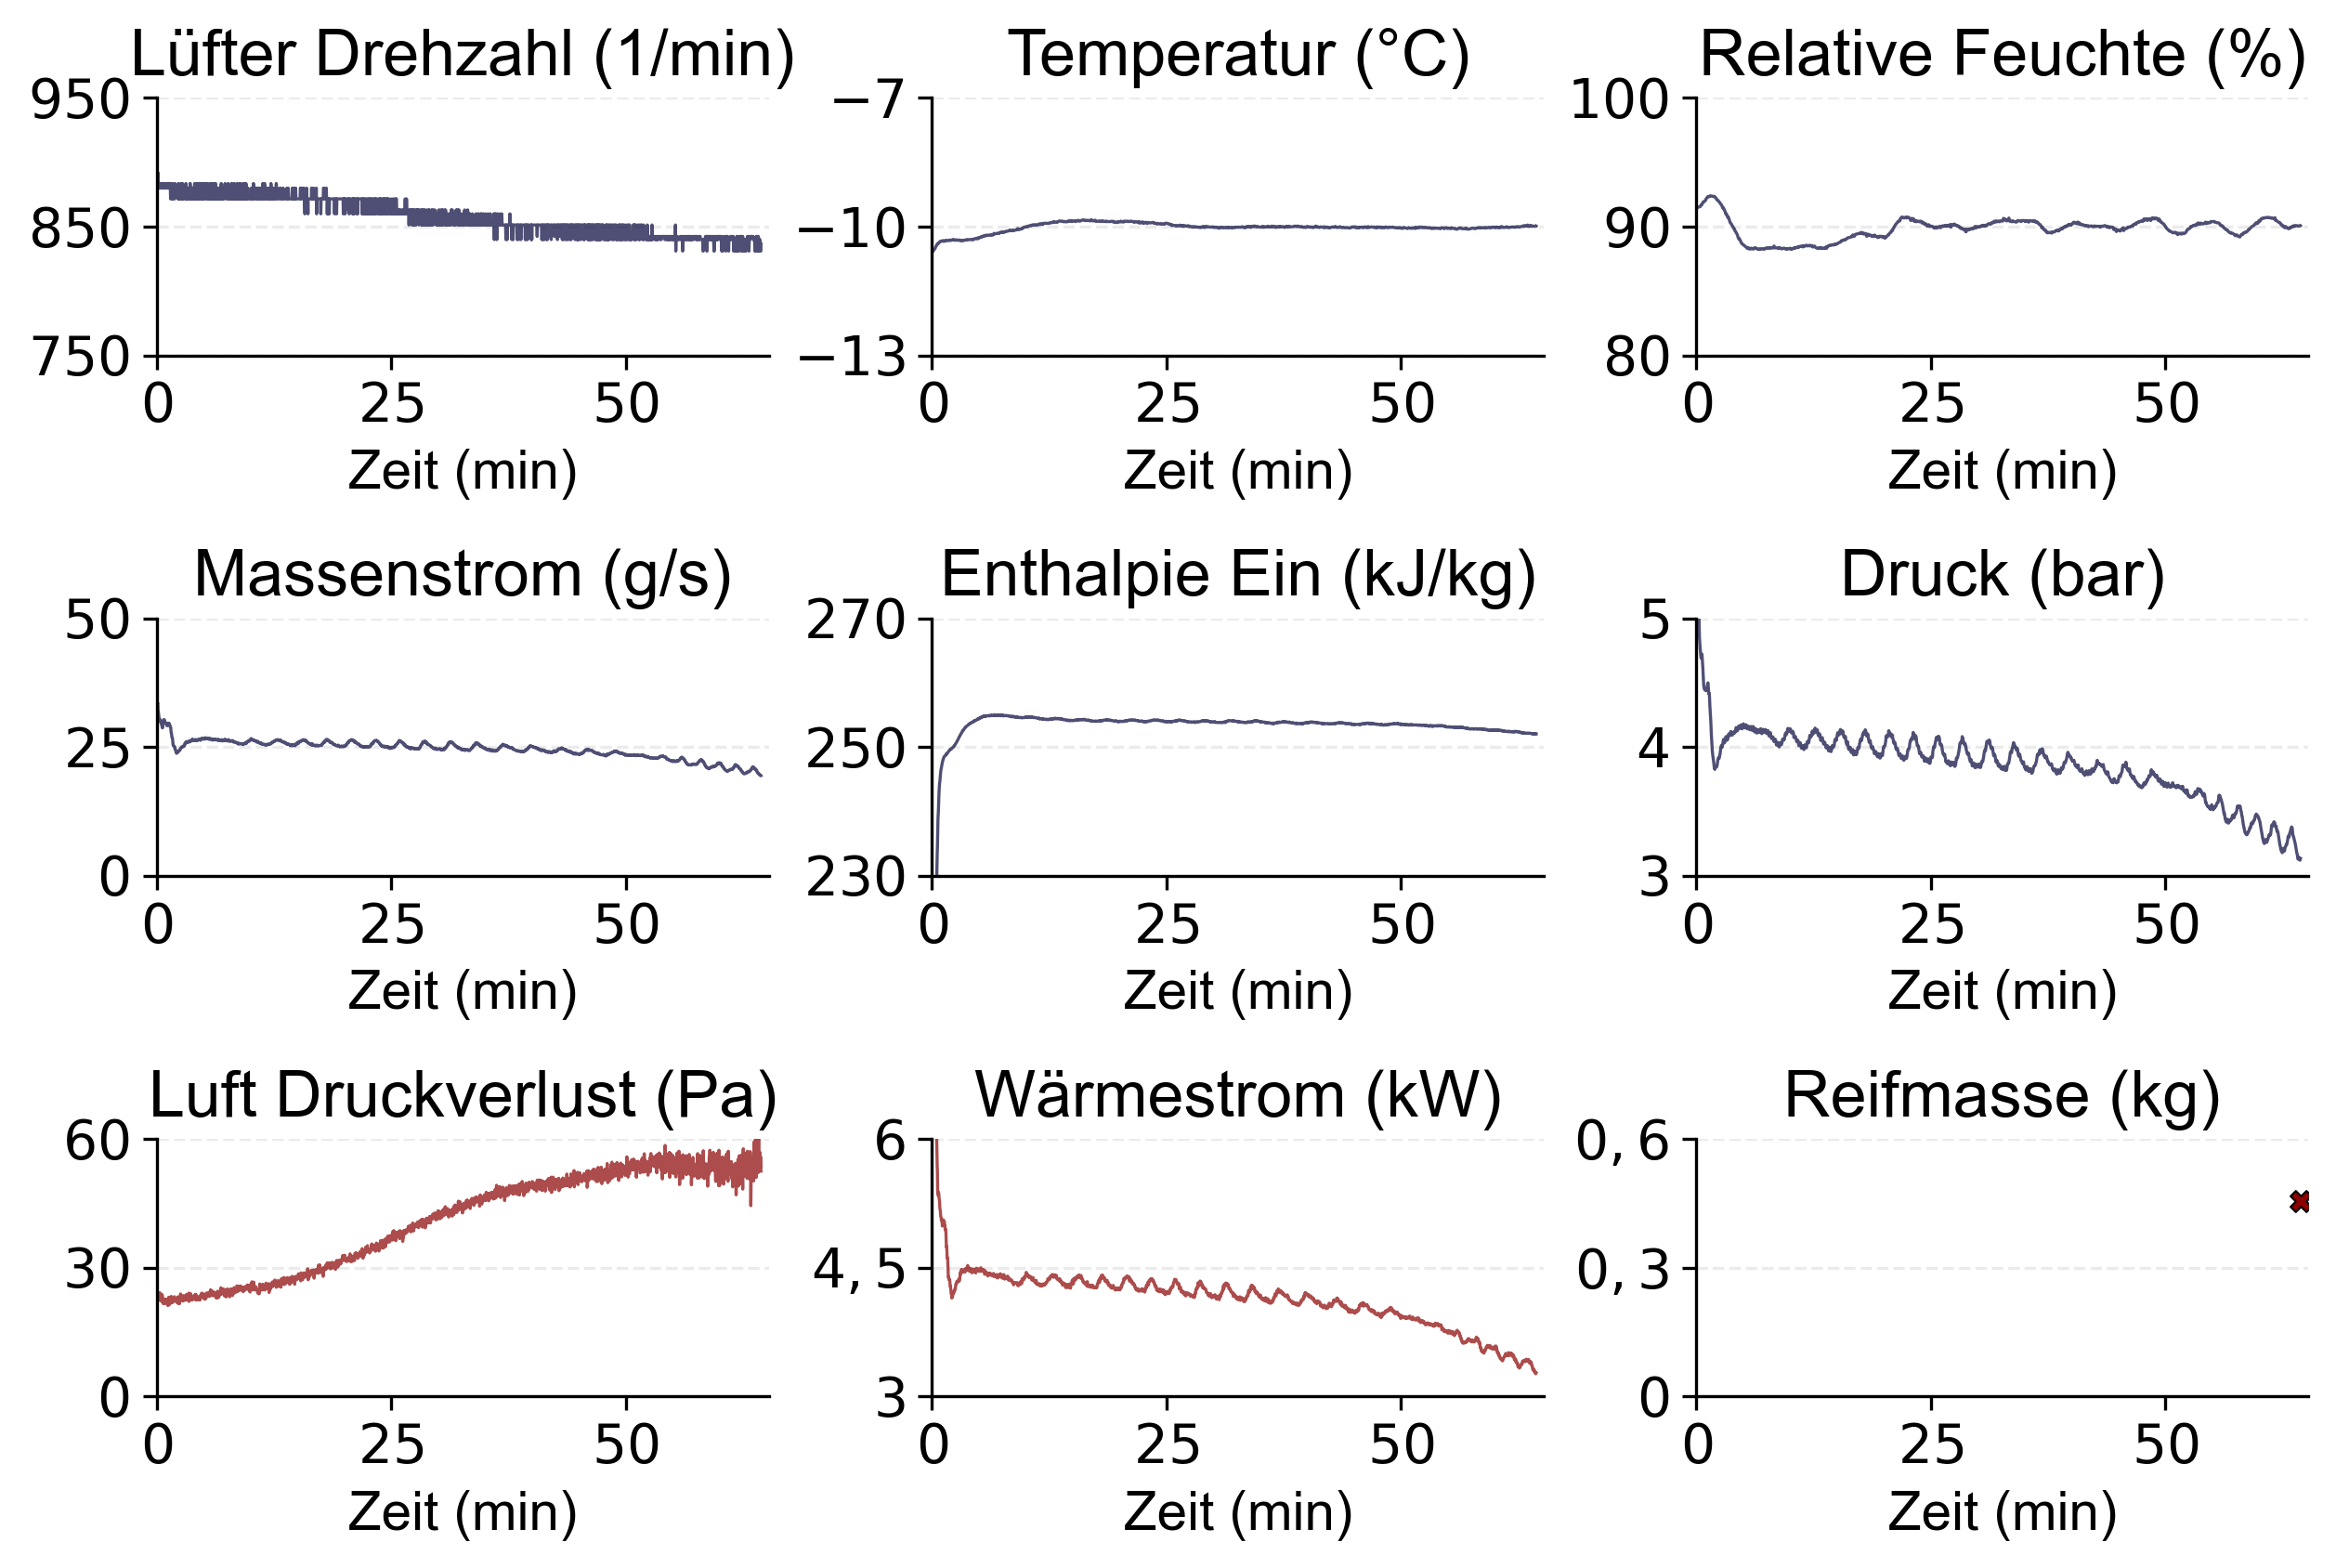

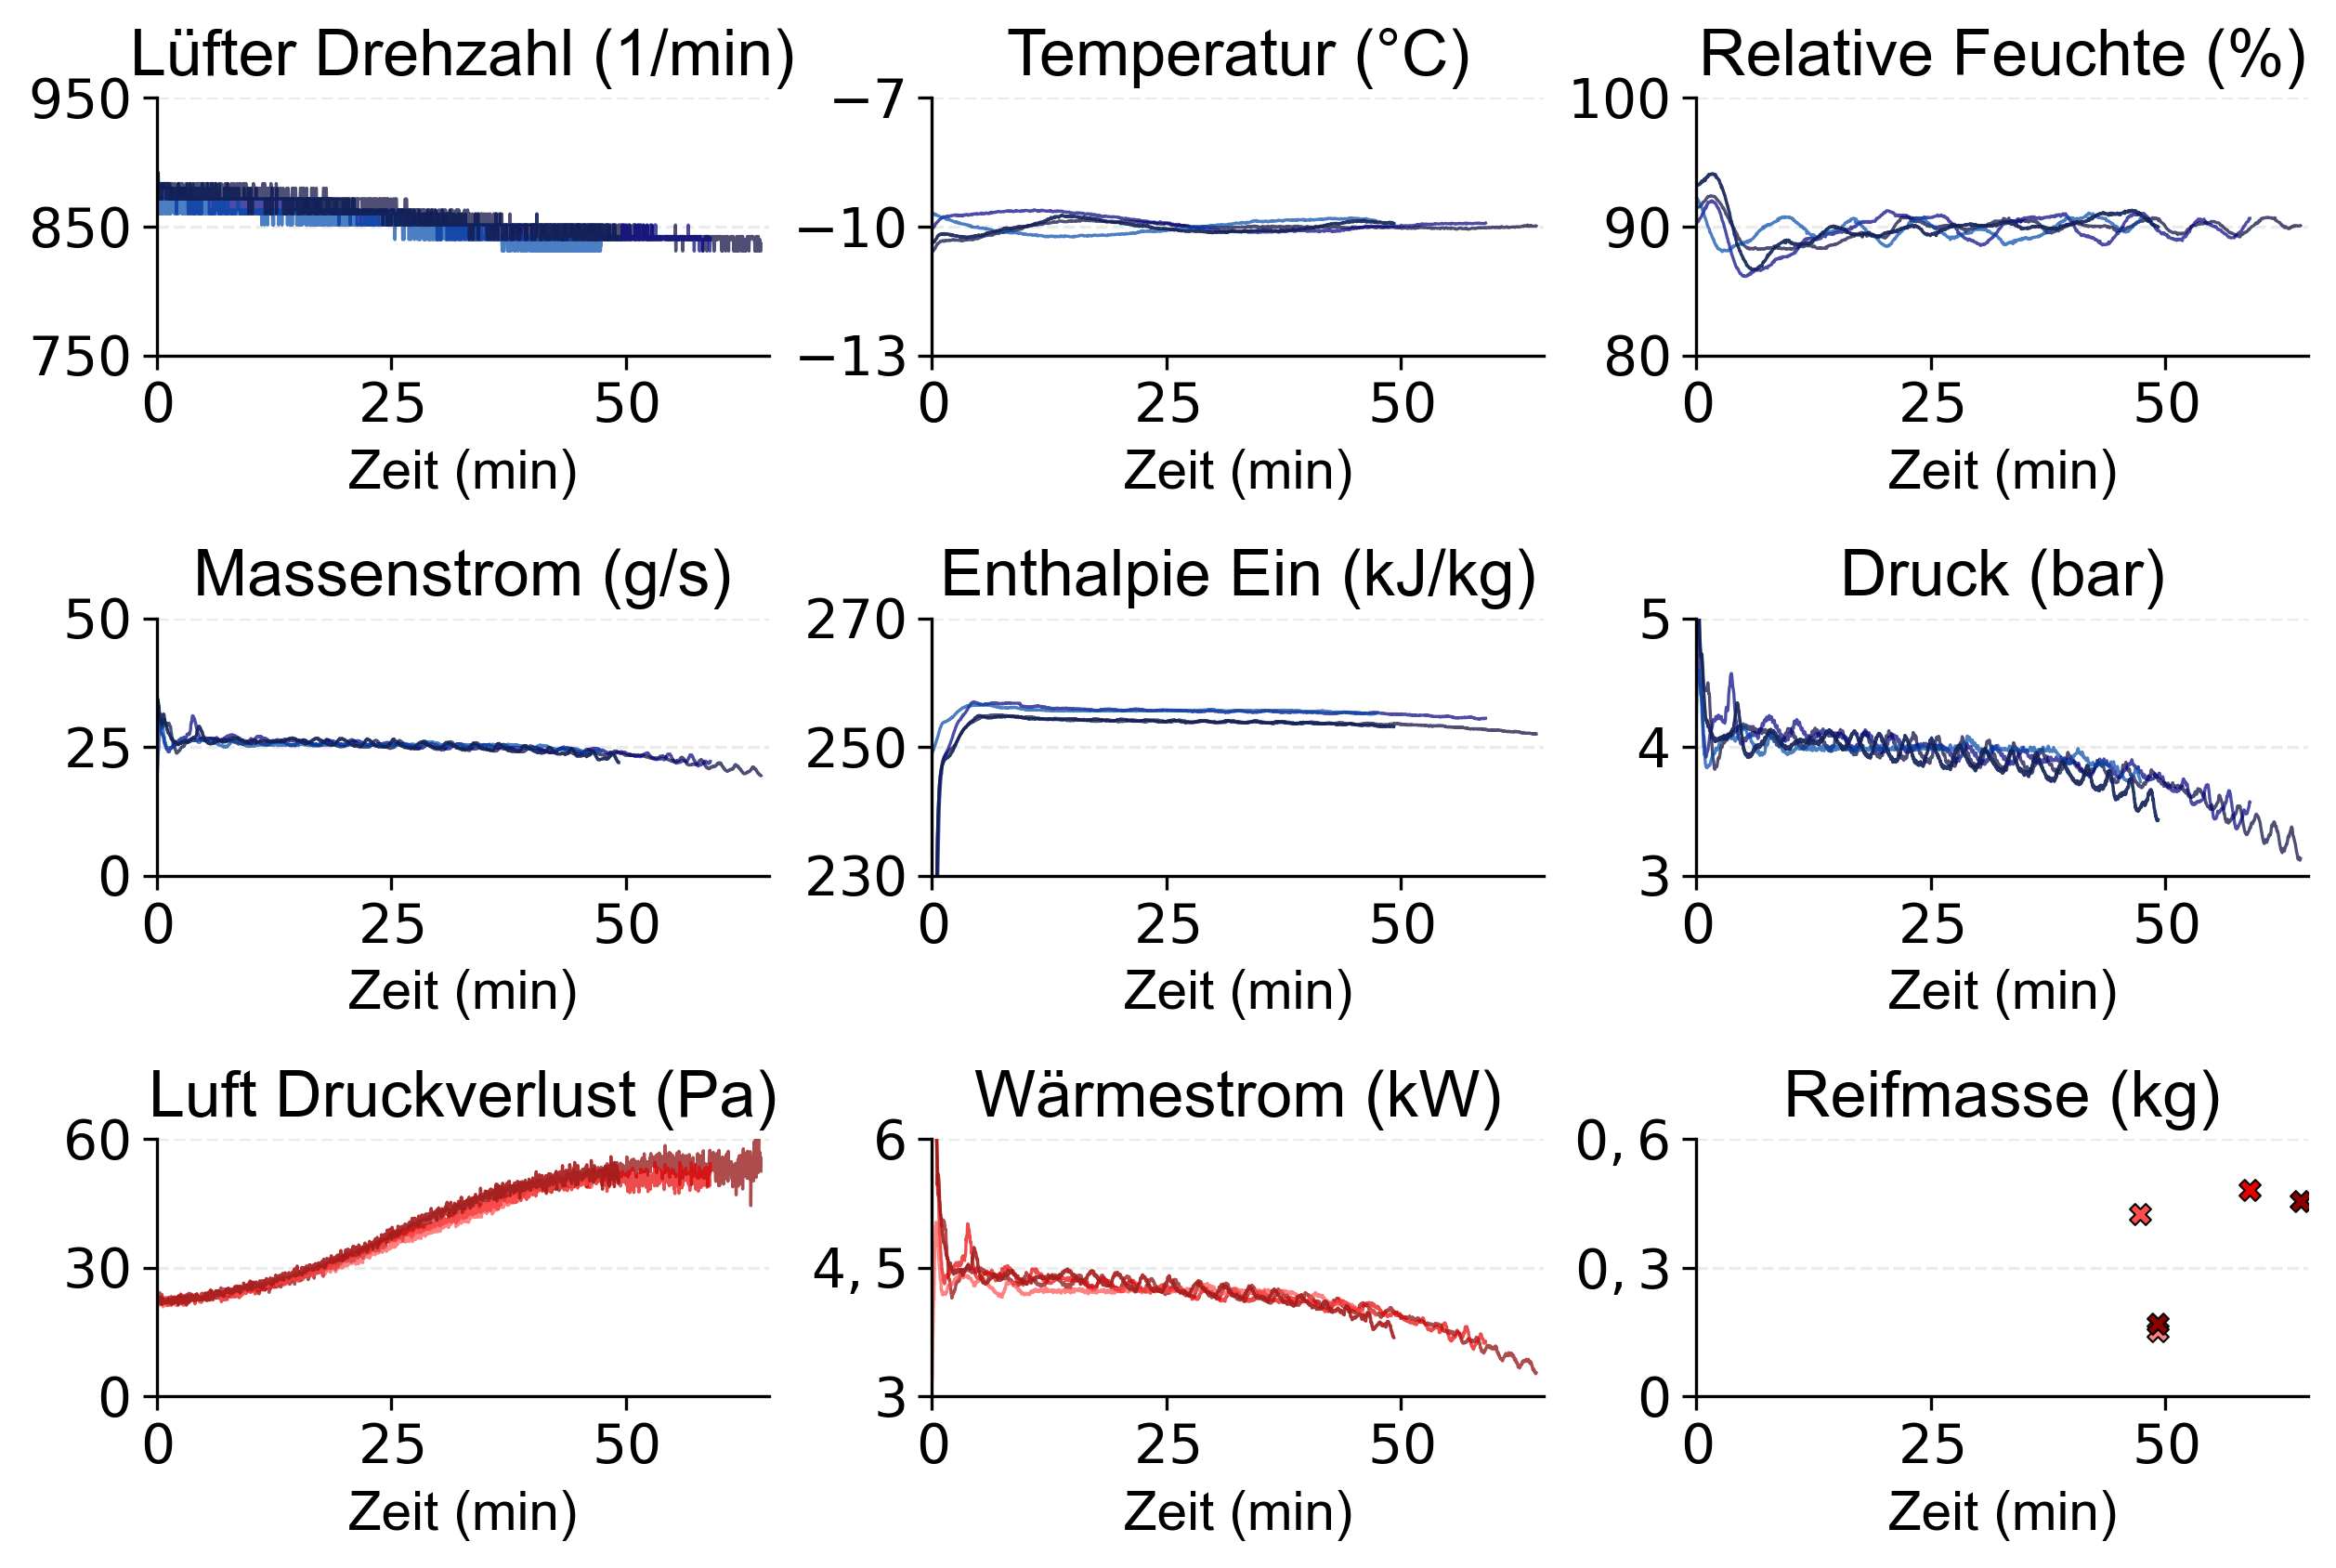

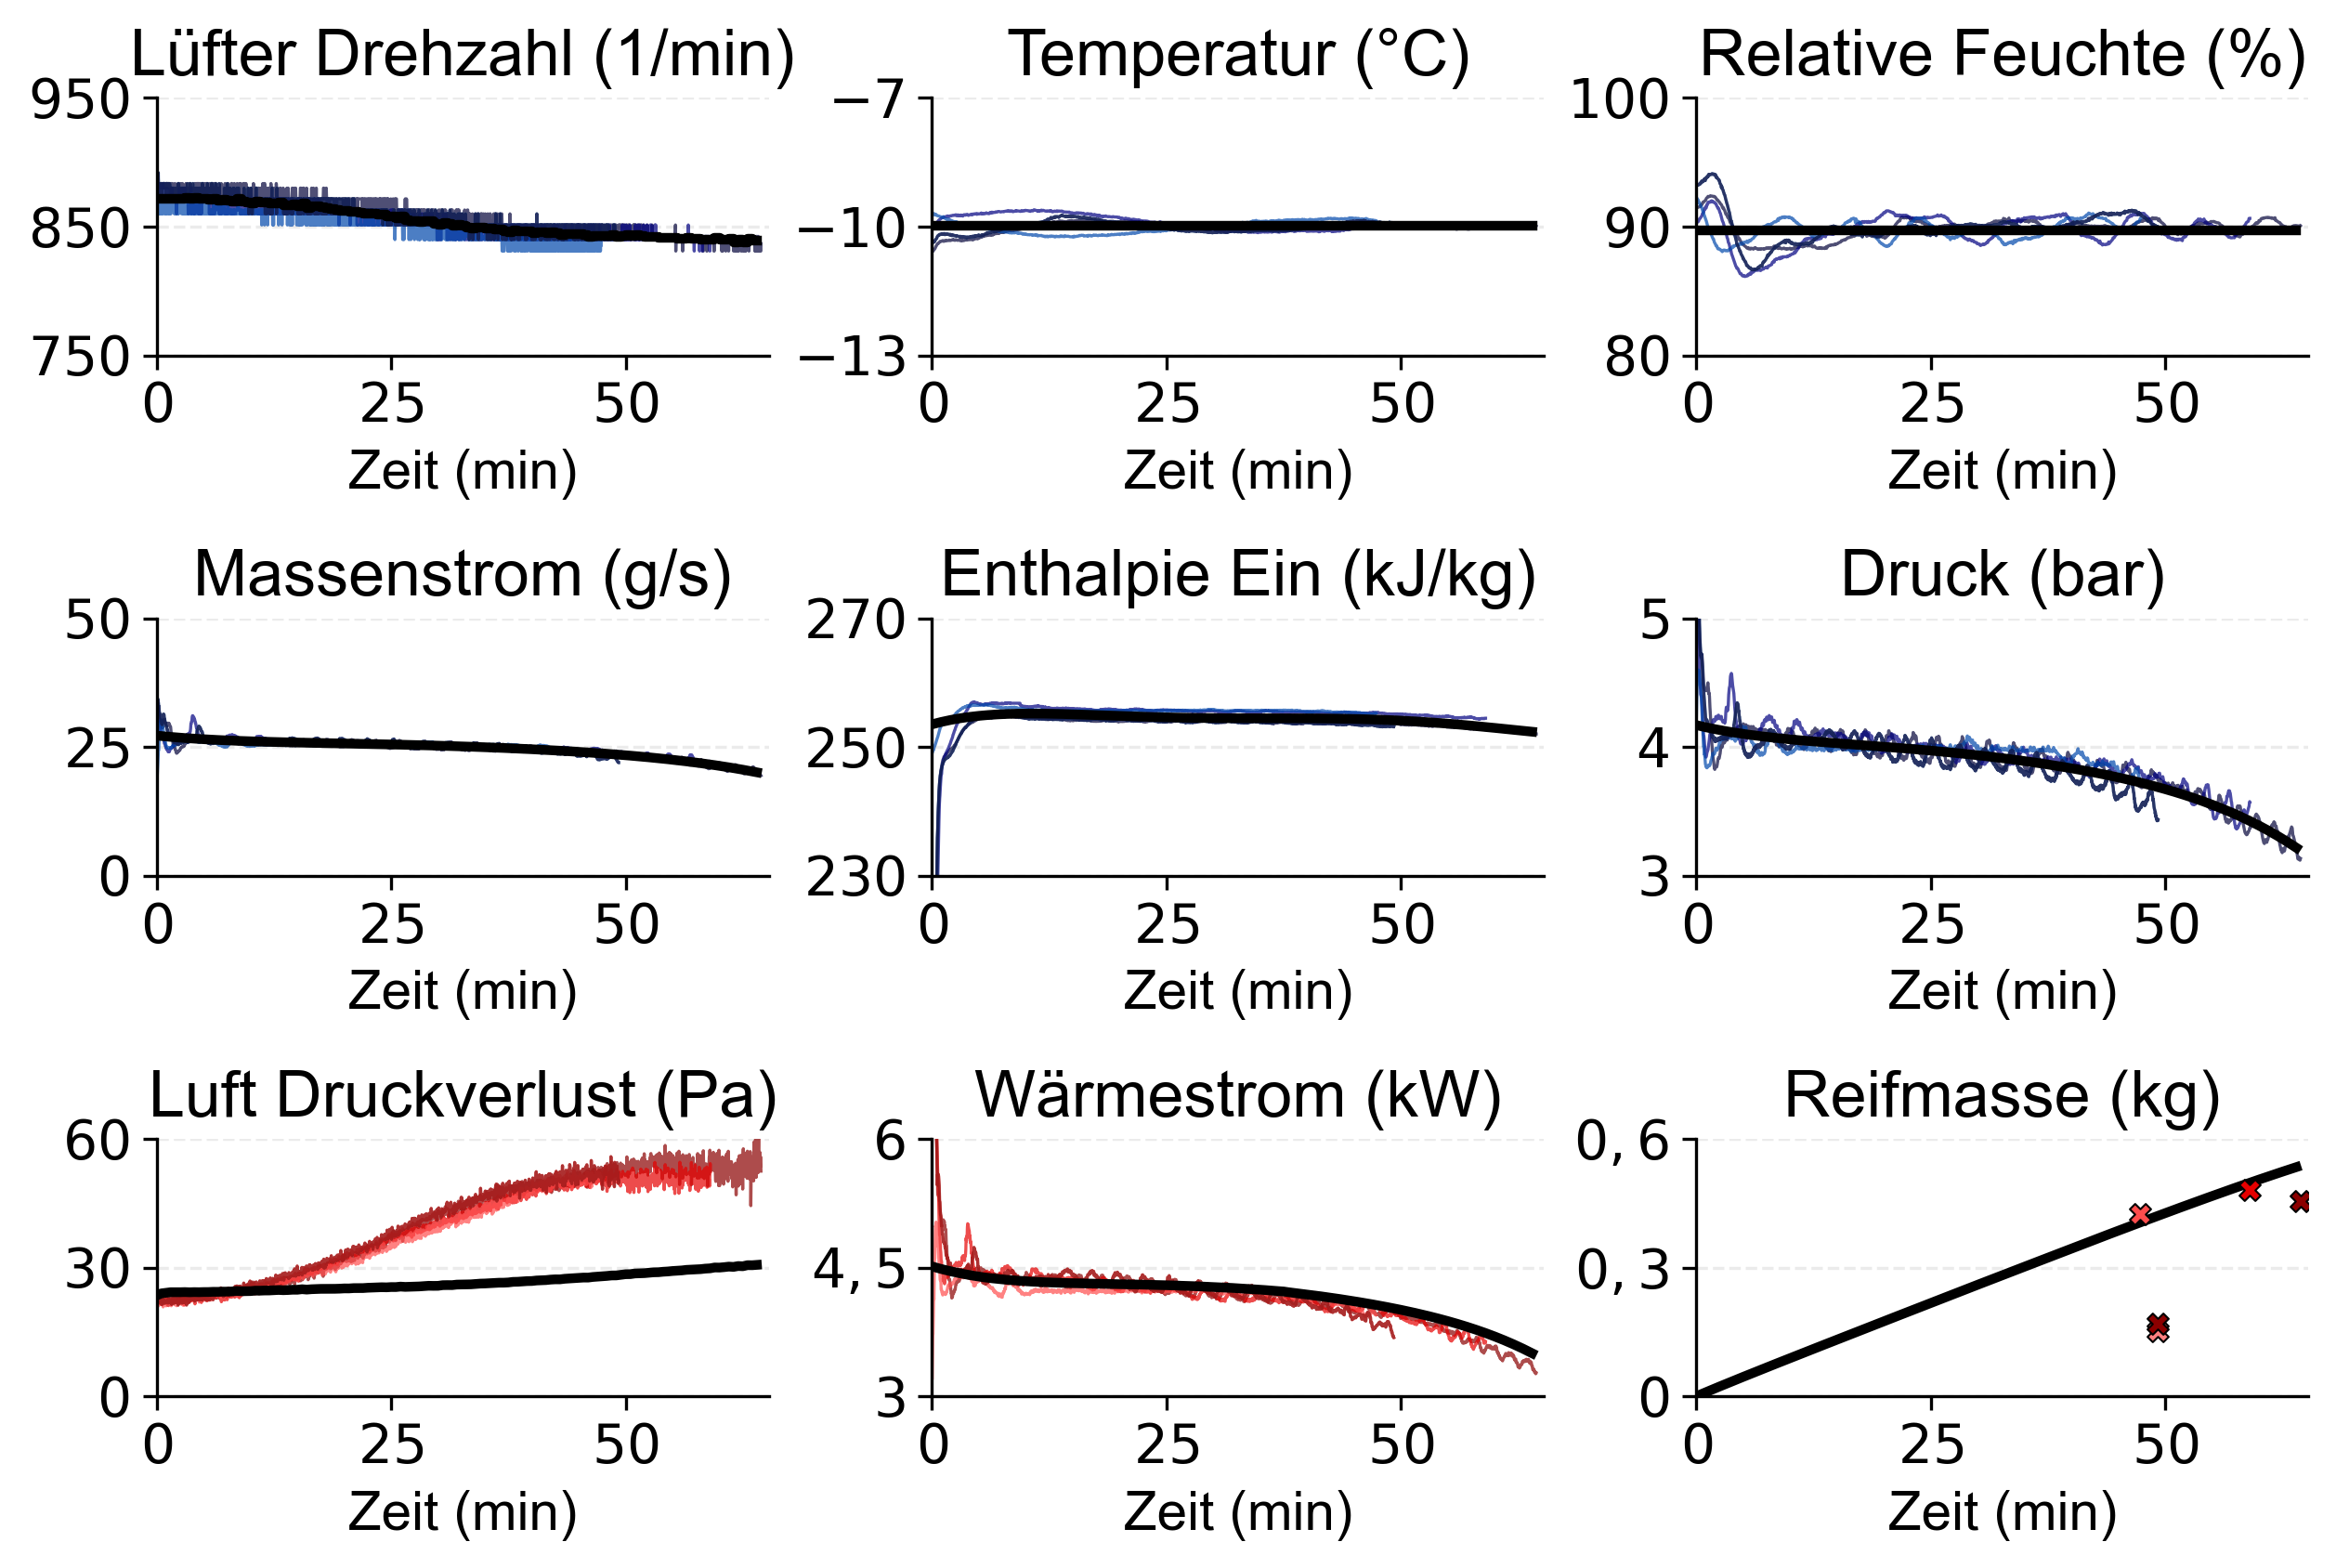

In [1]:
import pickle
import sys
import os
import pickle
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
from frost_evaporator import SimulationVisualizer


# --- Opti Abt ---

# Load the dictionary
with open("simulation_data/final/04_optiabt_validation_final.pkl", "rb") as f:
    abt_results = pickle.load(f)

group_names = list(abt_results.keys())
for group_name in group_names:

    # Get Data for the current group
    group_data   = abt_results[group_name]

    # Create a new visualizer instance
    viz_abt = SimulationVisualizer(group_data["params"])


    use_melted = False
    if group_name == "+3 °C" or group_name == "Abt-a":
        use_melted = True

    # if group_name == "+0 °C":
    #     viz_abt.plot_frost_distribution(group_data["states_history"], "4_Reifdicke_abt.pdf")

    clean_group_name = (
        group_name.replace("+", "plus")
                  .replace("-", "minus")
                  .replace("°C", "degC")
                  .replace(" ", "_")
    )
    output_filename = f"4_Validierungsplot_abt_{clean_group_name}.pdf"

    # # Plot the comparison using the loaded data
    # viz_abt.plot_comparison_thesis(states_history  = group_data["states_history"],
    #                             inputs_history  = group_data["inputs_history"], 
    #                             experiment_ids  = group_data["experiment_ids"], 
    #                             path_exp        = group_data["path_exp"], 
    #                             y_limits_dict   = None,
    #                             cutoff_pct      = group_data["cutoff_pct"], 
    #                             experiment_name = group_data["experiment_name"],
    #                             save_fig        = True, 
    #                             use_melted_mass = use_melted,
    #                             output_filename = output_filename,
    # )

    if group_name == "+0 °C":
        # Define exact ticks [min, mid, max] for all plots
        custom_ticks = {
            'n_fan':    [1100, 1300, 1500],
            'T_in':     [-3, 0, 3],
            'rh_in':    [70, 85, 100],
            'm_ref':    [0, 30e-3, 60e-3],
            'h_ref_in': [200, 220, 240],
            'p_ref_in': [1, 1.5, 2],
            'dp':       [0, 50, 100],
            'Q':        [4e3, 6e3, 8e3],
            'm_frost':  [0, 4e3, 8e3]
        }

        viz_abt.plot_comparison_powerpoint(
            states_history  = group_data["states_history"],
            inputs_history  = group_data["inputs_history"], 
            experiment_ids  = group_data["experiment_ids"], 
            path_exp        = group_data["path_exp"], 
            y_ticks_dict    = custom_ticks,
            cutoff_pct      = group_data["cutoff_pct"], 
            experiment_name = group_data["experiment_name"],
            save_fig        = True, 
            use_melted_mass = use_melted,
            output_filename = output_filename
        )

    # if group_name == "-7 °C":
    #     # viz_abt.plot_frost_distribution(group_data["states_history"], "temp.pdf")
    #     viz_abt.animate_frost_distribution(group_data["states_history"], "frost_evolution_minus7C.mp4")



# # --- OptiHorst ---

# Load the dictionary
with open("simulation_data/final/04_optihorst_validation_final.pkl", "rb") as f:
    horst_results = pickle.load(f)

group_names = list(horst_results.keys())
for group_name in group_names:

    # Get Data for the current group
    group_data   = horst_results[group_name]

    # Create a new visualizer instance
    viz_horst = SimulationVisualizer(group_data["params"])

    # if group_name == "-10°C":
    #     viz_horst.plot_frost_distribution(group_data["states_history"],
    #                                     "4_Reifdicke_horst.pdf")

    clean_group_name = (
        group_name.replace("+", "plus")
                  .replace("-", "minus")
                  .replace("°C", "degC")
                  .replace(" ", "_")
    )
    output_filename = f"4_Validierungsplot_horst_{clean_group_name}.pdf"

    # # # Plot the comparison using the loaded data
    # viz_horst.plot_comparison_thesis(states_history  = group_data["states_history"],
    #                                  inputs_history  = group_data["inputs_history"], 
    #                                  experiment_ids  = group_data["experiment_ids"], 
    #                                  path_exp        = group_data["path_exp"], 
    #                                  y_limits_dict   = None,
    #                                  cutoff_pct      = group_data["cutoff_pct"], 
    #                                  experiment_name = group_data["experiment_name"],
    #                                  save_fig        = True, 
    #                                  output_filename = output_filename,
    # )

    if group_name == "-10°C":

        # Define exact ticks [min, mid, max] for all plots
        custom_ticks = {
            'n_fan':    [750, 850, 950],
            'T_in':     [-13, -10, -7],
            'rh_in':    [80, 90, 100],
            'm_ref':    [0, 25e-3, 50e-3],
            'h_ref_in': [230, 250, 270],
            'p_ref_in': [3, 4, 5],
            'dp':       [0, 30, 60],
            'Q':        [3e3, 4.5e3, 6e3],
            'm_frost':  [0, 0.3e3, 0.6e3]
        }

        viz_horst.plot_comparison_powerpoint(
            states_history  = group_data["states_history"],
            inputs_history  = group_data["inputs_history"], 
            experiment_ids  = group_data["experiment_ids"], 
            path_exp        = group_data["path_exp"], 
            y_ticks_dict    = custom_ticks,
            cutoff_pct      = group_data["cutoff_pct"], 
            experiment_name = group_data["experiment_name"],
            save_fig        = True, 
            output_filename = output_filename,
        )



# Big 9x3 relative Error Plot

Generating plots: 100%|██████████| 9/9 [00:32<00:00,  3.65s/it]


Plot erfolgreich gespeichert unter: J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken\4_3_by_9_plot.pdf


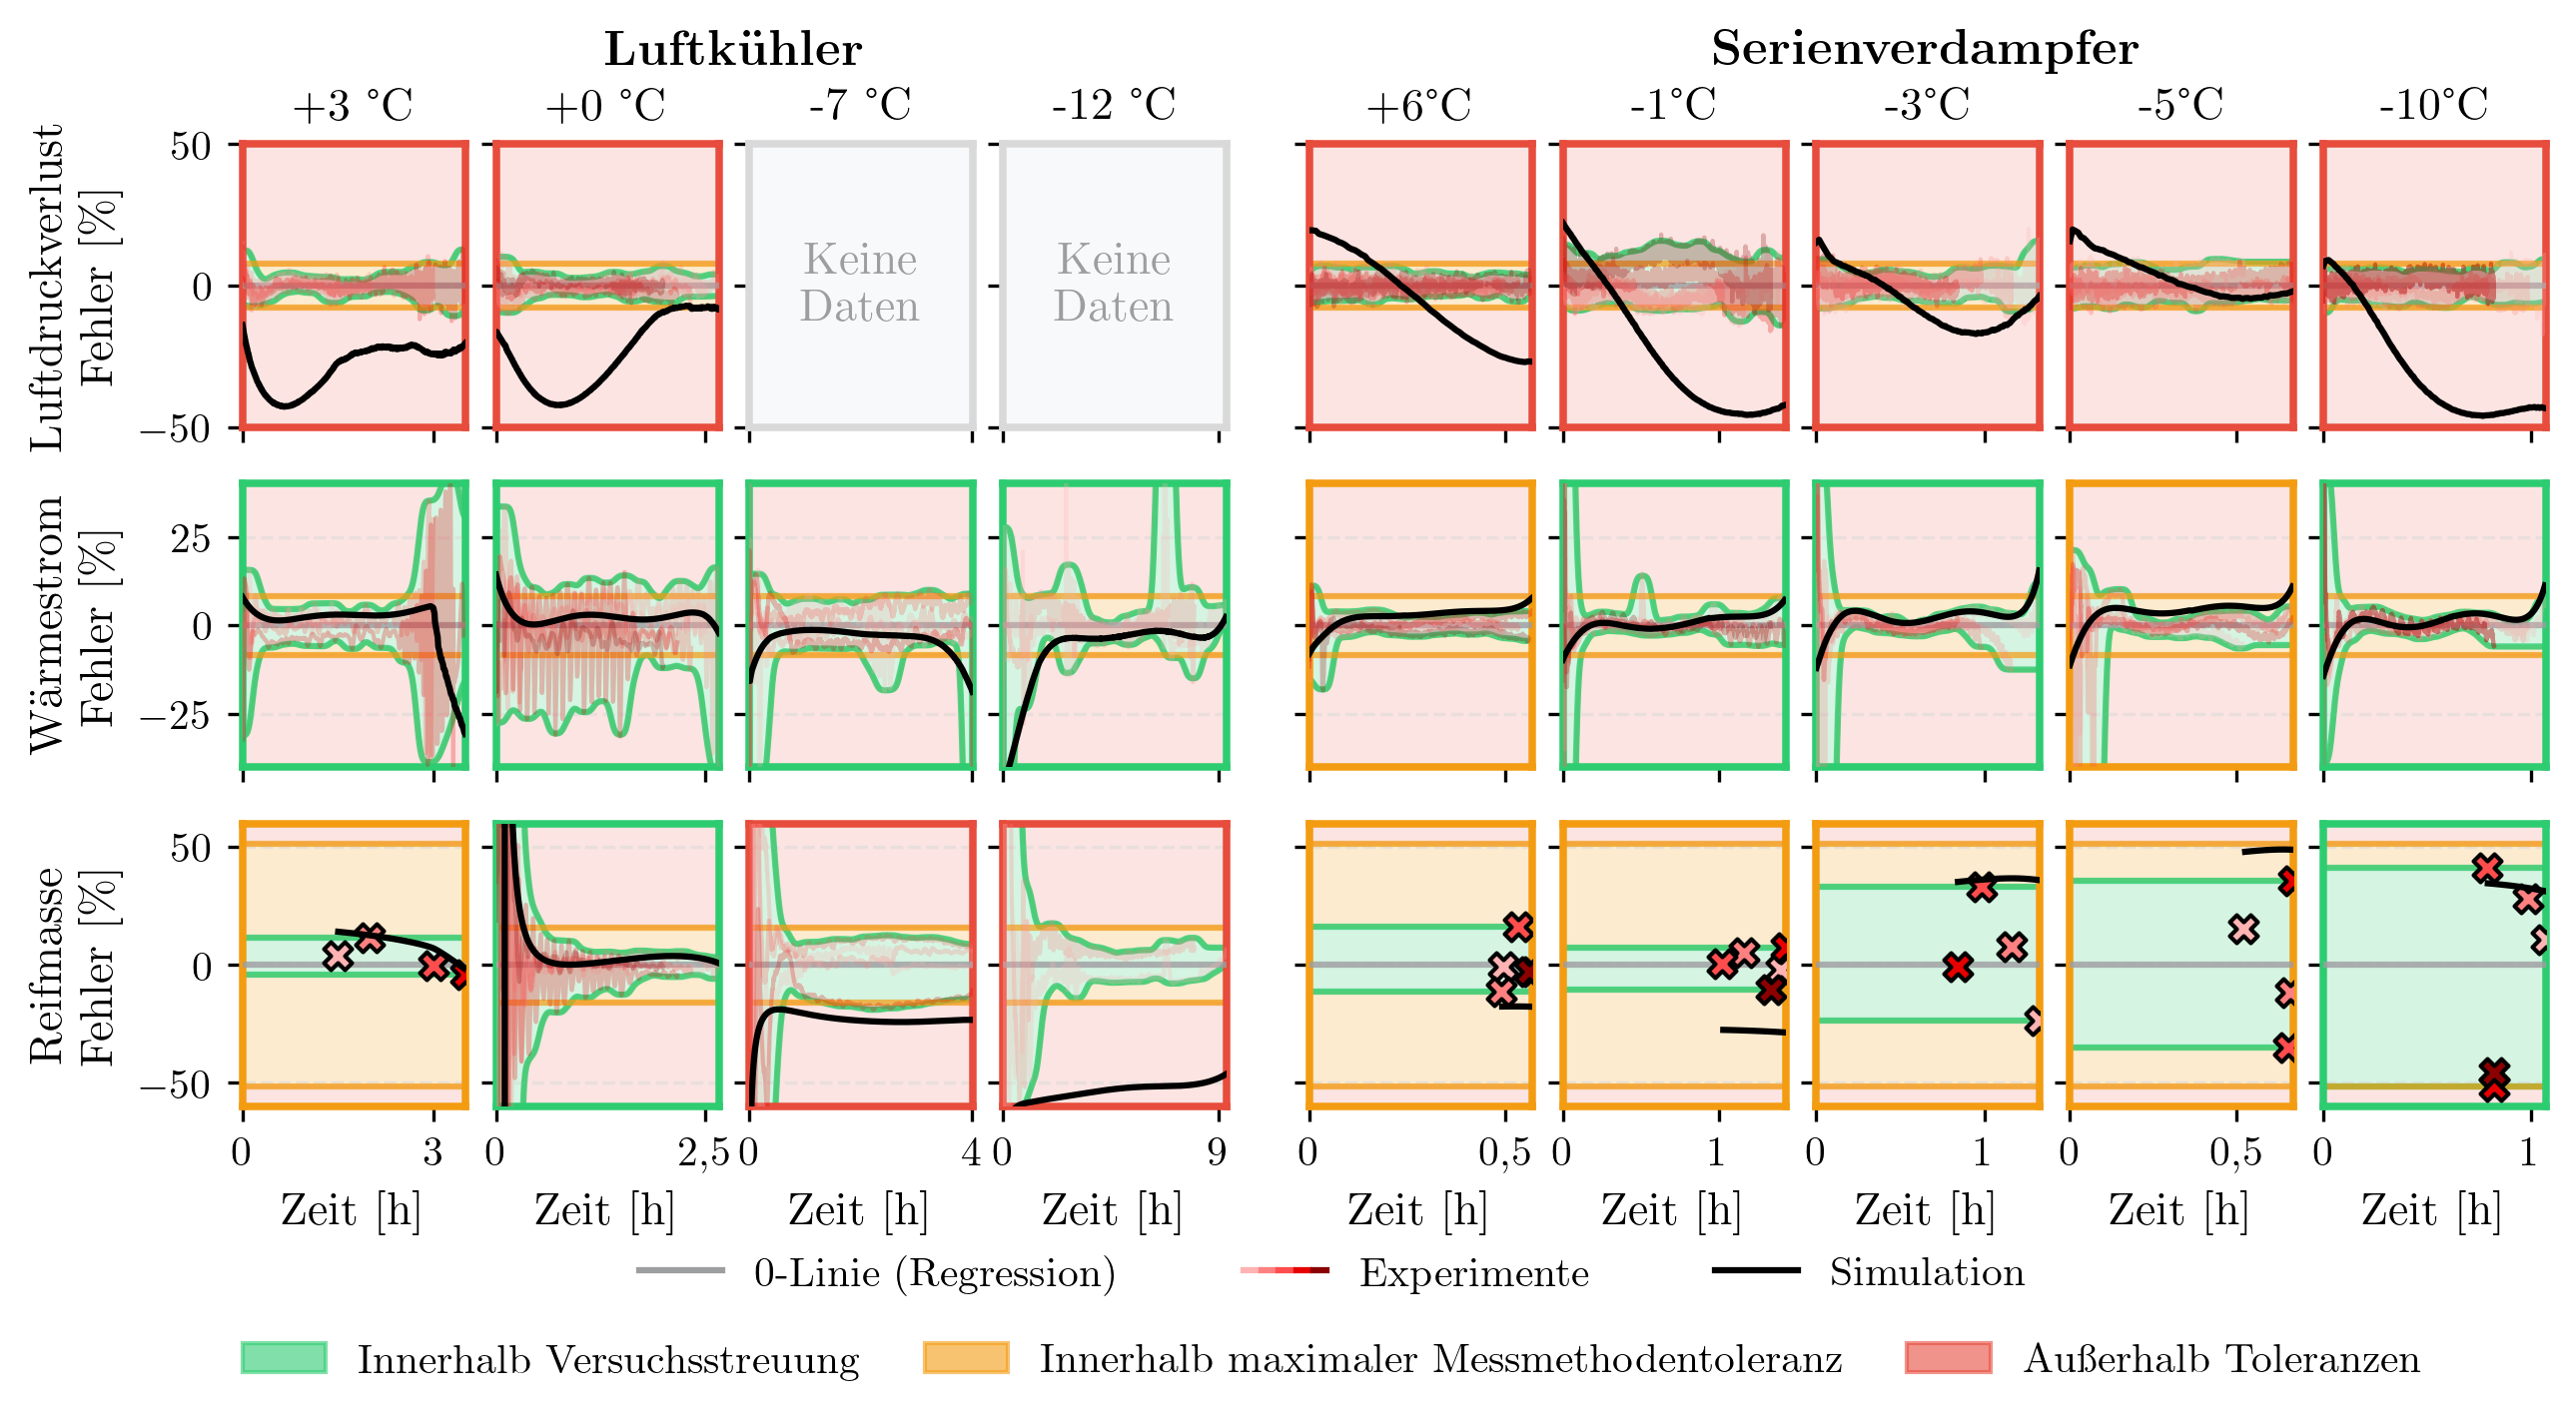


 📊 SIMULATION QUALITY SUMMARY
 🟢 Green  (Excellent) : 9 metrics
 🟠 Orange (Acceptable): 7 metrics
 🔴 Red    (Poor)      : 11 metrics
 ⚪ Gray   (No Data)   : 0 metrics



In [1]:
import pickle
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import SimulationVisualizer

# --- 1. Load Data ---
with open("simulation_data/final/04_optiabt_validation_final.pkl", "rb") as f:
    abt_results = pickle.load(f)

with open("simulation_data/final/04_optihorst_validation_final.pkl", "rb") as f:
    horst_results = pickle.load(f)

# Globalen Plot Style aktivieren! (Sehr wichtig, um die rcParams zu laden)
# Da wir Instanzen später erzeugen, rufen wir es einmal via Dummy auf oder nutzen die Matplotlib rcParams.
dummy_viz = SimulationVisualizer({})
dummy_viz.set_plot_style()

# --- 2. Consolidate into a single list ---
combined_runs = []

for group_name, group_data in abt_results.items():
    use_melted = group_name in ["+3 °C", "Abt-a"]
    combined_runs.append({
        "data": group_data, "name": group_name, 
        "exp_name": "OptiAbt", "use_melted": use_melted
    })

for group_name, group_data in horst_results.items():
    combined_runs.append({
        "data": group_data, "name": group_name, 
        "exp_name": "OptiHorst", "use_melted": False
    })

measurement_errors = {
    'dp': 7.69,
    'Q': 8.32,
    'm_frost_dyn': 15.89,
    'm_frost_melt': 51.51
}

# --- 3. Create the Master Figure ---
split_idx = len(abt_results) 
num_cols = len(combined_runs) + 1 
widths = [1.0] * num_cols
widths[split_idx] = 0.1

cm_to_inch = 1 / 2.54
landscape_width_cm = 21.0 
height_cm = 12.0

fig, axes = plt.subplots(
    nrows=3, 
    ncols=num_cols, 
    figsize=(landscape_width_cm * cm_to_inch, height_cm * cm_to_inch),
    sharex='col', 
    sharey='row',
    gridspec_kw={'width_ratios': widths}
)

# --- 4. Plot each group ---
total_counts = {'green': 0, 'orange': 0, 'red': 0, 'gray': 0}

for col_idx, run in enumerate(tqdm(combined_runs, desc="Generating plots")):
    target_col = col_idx if col_idx < split_idx else col_idx + 1
    
    group_data = run["data"]
    viz = SimulationVisualizer(group_data["params"])
    
    run_counts = viz.plot_error_to_experiment_combined(
        states_history  = group_data["states_history"],
        inputs_history  = group_data["inputs_history"], 
        experiment_ids  = group_data["experiment_ids"], 
        path_exp        = group_data["path_exp"], 
        cutoff_pct      = group_data["cutoff_pct"], 
        experiment_name = run["exp_name"],
        group_name      = run["name"], 
        save_fig        = False, 
        use_melted_mass = run["use_melted"],
        target_axes     = axes[:, target_col],
        is_first_col    = (target_col == 0),
        is_title_col    = (target_col == 0 or target_col == split_idx + 1),
        meas_errors     = measurement_errors
    )
    
    total_counts['green'] += run_counts['green']
    total_counts['orange'] += run_counts['orange']
    total_counts['red'] += run_counts['red']
    total_counts['gray'] += run_counts['gray']

# Leere Spalte unsichtbar machen
for ax in axes[:, split_idx]:
    ax.axis('off')

# =========================================================================
# --- 5. Layout, Titel & Legende ---
# =========================================================================

# Ränder anpassen: Unten viel Platz für die Legende, oben etwas Platz für die neuen Titel
fig.subplots_adjust(
    left=0.06, 
    right=0.99,
    bottom=0.20, # Platz nach unten erweitert
    top=0.88,    # Platz nach oben für die Haupt-Titel geschaffen
    hspace=0.2, 
    wspace=0.15
)

# 1. Zwinge Matplotlib, das Canvas einmal zu "zeichnen", damit wir die exakten X/Y Koordinaten abrufen können
fig.canvas.draw()

# 2. X-Koordinaten für die Titel exakt mittig über die Blöcke berechnen
pos1_start = axes[0, 0].get_position()
pos1_end = axes[0, split_idx - 1].get_position()
x_center1 = (pos1_start.x0 + pos1_end.x1) / 2

pos2_start = axes[0, split_idx + 1].get_position()
pos2_end = axes[0, num_cols - 1].get_position()
x_center2 = (pos2_start.x0 + pos2_end.x1) / 2

# Y-Koordinate knapp über dem obersten Plot-Rand positionieren
y_pos = pos1_start.y1 + 0.05

# 3. Titel setzen (Mittig, Fett über LaTeX)
fig.text(x_center1, y_pos, r"\textbf{Luftkühler}", ha='center', va='bottom', fontsize=12)
fig.text(x_center2, y_pos, r"\textbf{Serienverdampfer}", ha='center', va='bottom', fontsize=12)

# --- Globale Legende erstellen ---
sim_line = mlines.Line2D([], [], color='black', lw=1.5)
red_colors = ['#FFB3B3', '#FF8080', '#FF4D4D', '#E60000', '#8B0000']
exp_lines = tuple(mlines.Line2D([], [], color=c, lw=1.5) for c in red_colors)
baseline_line = mlines.Line2D([], [], color='#9D9EA0', lw=1.5)

green_patch = mpatches.Patch(color='#2ECC71', alpha=0.6)
orange_patch = mpatches.Patch(color='#F39C12', alpha=0.6)
red_patch = mpatches.Patch(color='#E74C3C', alpha=0.6)

# 1. Top Legend (Lines)
handles_lines = [baseline_line, exp_lines, sim_line]
labels_lines = ['0-Linie (Regression)', 'Experimente', 'Simulation']

fig.legend(
    handles=handles_lines, 
    labels=labels_lines, 
    loc='lower center', 
    ncol=3,
    bbox_to_anchor=(0.5, 0.04), # Positioned slightly above the bottom legend
    frameon=False, 
    fontsize=10,
    columnspacing=3.0, # Adjust this value to bring the top items closer together or further apart
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)} 
)

# 2. Bottom Legend (Patches)
handles_patches = [green_patch, orange_patch, red_patch]
labels_patches = ['Innerhalb Versuchsstreuung', 'Innerhalb maximaler Messmethodentoleranz', 'Außerhalb Toleranzen']

fig.legend(
    handles=handles_patches, 
    labels=labels_patches, 
    loc='lower center', 
    ncol=3,
    bbox_to_anchor=(0.5, -0.02), # Positioned at the very bottom
    frameon=False, 
    fontsize=10,
    columnspacing=1.5 # Independent spacing for the long text items
)

# --- 6. EXPORT FÜR MASTERARBEIT ---
output_dir = r"J:\Masterarbeit_Nils_Baumeister\02_Schriftliche_Ausarbeitung\Graphiken"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "4_3_by_9_plot.pdf")

plt.savefig(save_path, bbox_inches='tight')
print(f"Plot erfolgreich gespeichert unter: {save_path}")

plt.show()

print("\n" + "="*40)
print(" 📊 SIMULATION QUALITY SUMMARY")
print("="*40)
print(f" 🟢 Green  (Excellent) : {total_counts['green']} metrics")
print(f" 🟠 Orange (Acceptable): {total_counts['orange']} metrics")
print(f" 🔴 Red    (Poor)      : {total_counts['red']} metrics")
print(f" ⚪ Gray   (No Data)   : {total_counts['gray']} metrics")
print("="*40 + "\n")